In [1]:
import scanpy as sc

Matplotlib created a temporary cache directory at /tmp/matplotlib-x138zwx1 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
adata=sc.read_h5ad('/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/Immunecells_without_regress_out/FINAL_Objects_Annotated_Without_RO/FINAL_Baboon_Lymphoids_Annotated_Without_RO.h5ad')

In [3]:
adata


AnnData object with n_obs × n_vars = 3774 × 3241
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'new_endpoints', 'leiden_06', 'leiden_12', 'leiden_10', 'leiden_07', 'leiden_01', 'leiden_named_07', 'leiden_named_10', 'leiden_named_12', 'leiden', 'leiden_08', 'leiden_named_08'
    var: 'Average_expression', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sample_ID_colors', 'hvg', 'leiden', 'leiden_01', 'leiden_01_colors', 'leiden_02', 'leiden_02_c

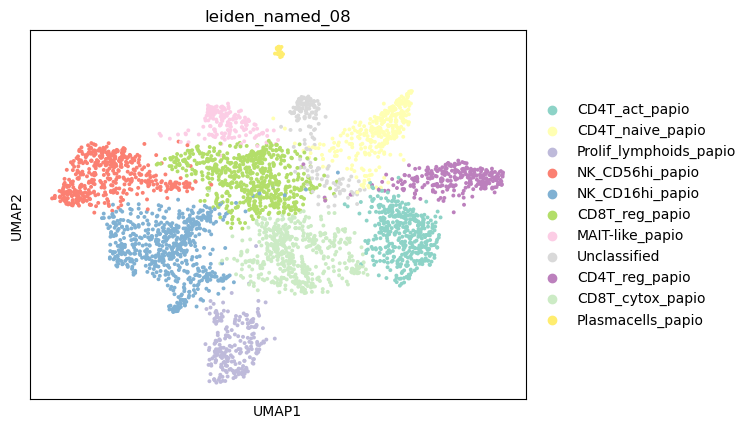

In [6]:
sc.pl.umap(adata, color='leiden_named_08')


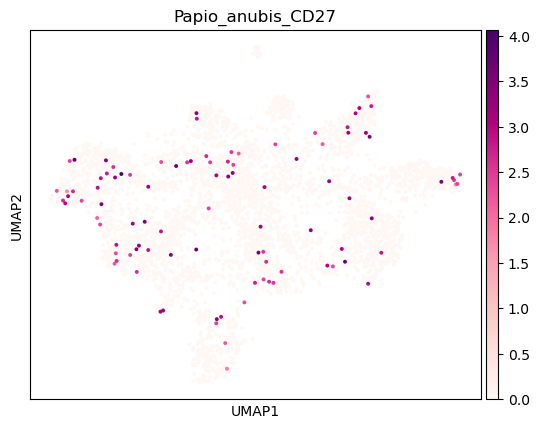

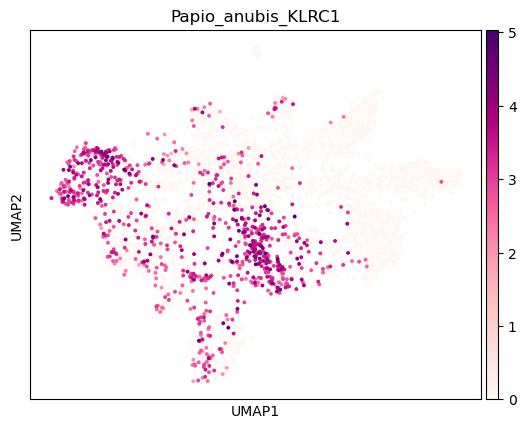

In [5]:
sc.pl.umap(LYMPHOIDS_harmony, color='Papio_anubis_CD27', cmap='RdPu', wspace=0.1, ncols=5)
sc.pl.umap(LYMPHOIDS_harmony, color='Papio_anubis_KLRC1', cmap='RdPu', wspace=0.1, ncols=5)

# Set up gene set scoring for annotation

In [9]:
import pandas as pd
import scanpy as sc

def calculate_gene_set_score(adata, gene_set, score_name):
    # Ensure all genes in the set are present in the data
    valid_genes = [gene for gene in gene_set if gene in adata.var_names]
    
    if len(valid_genes) == 0:
        print(f"No valid genes found in the gene set '{score_name}'. Please check gene names.")
        return None
    
    sc.tl.score_genes(adata, valid_genes, score_name=score_name)
    print(f"Gene set score '{score_name}' calculated using {len(valid_genes)} genes.")
    print(f"Valid genes: {', '.join(valid_genes)}")
    
    # Calculate mean expression for each gene
    gene_scores = adata[:, valid_genes].X.mean(axis=0)
    
    # Create a DataFrame with gene names and their scores
    gene_score_df = pd.DataFrame({
        'Gene': valid_genes,
        'Mean Expression': gene_scores.flatten()
    })
    
    # Sort the DataFrame by score in descending order
    gene_score_df = gene_score_df.sort_values('Mean Expression', ascending=False)
    
    # Display the table
    print("\nGene Scores:")
    print(gene_score_df.to_string(index=False))
    
    return valid_genes, gene_score_df


In [10]:
import pandas as pd
import scanpy as sc
import numpy as np

def calculate_gene_set_score(adata, gene_set, score_name):
    # Ensure all genes in the set are present in the data
    valid_genes = [gene for gene in gene_set if gene in adata.var_names]
    
    if len(valid_genes) == 0:
        print(f"No valid genes found in the gene set '{score_name}'. Please check gene names.")
        return None
    
    sc.tl.score_genes(adata, valid_genes, score_name=score_name)
    print(f"Gene set score '{score_name}' calculated using {len(valid_genes)} genes.")
    print(f"Valid genes: {', '.join(valid_genes)}")
    
    # Calculate mean expression and variance for each gene
    gene_means = adata[:, valid_genes].X.mean(axis=0)
    gene_vars = adata[:, valid_genes].X.var(axis=0)
    
    # Create a DataFrame with gene names, their mean scores, and variances
    gene_score_df = pd.DataFrame({
        'Gene': valid_genes,
        'Mean Expression': gene_means.flatten(),
        'Variance': gene_vars.flatten()
    })
    
    # Calculate coefficient of variation (CV)
    gene_score_df['CV'] = np.sqrt(gene_score_df['Variance']) / gene_score_df['Mean Expression']
    
    # Sort the DataFrame by mean expression in descending order
    gene_score_df = gene_score_df.sort_values('Mean Expression', ascending=False)
    
    # Display the table
    print("\nGene Scores:")
    print(gene_score_df.to_string(index=False))
    
    return valid_genes, gene_score_df


# CD 4 and CD 8 positive

In [13]:
LYMPHOIDS_harmony = adata

In [11]:
gene_set_CD4_pos = ['Papio_anubis_CD4']

Gene set score 'CD4_pos_score' calculated using 1 genes.
Valid genes: Papio_anubis_CD4

Gene Scores:
            Gene  Mean Expression  Variance         CV
Papio_anubis_CD4     3.436664e-08  0.999735 29094126.0


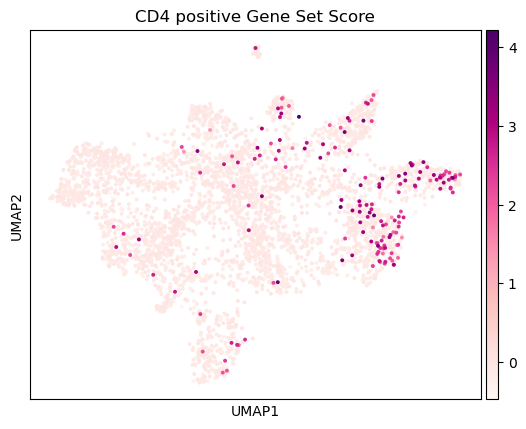

In [14]:
# Calculate score for CD4 activated gene set
valid_cd4_pos_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD4_pos, 'CD4_pos_score')

# Visualize the results
if valid_cd4_pos_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD4_pos_score', cmap='RdPu', wspace=0.1, ncols=5, title='CD4 positive Gene Set Score')

# Implementation of statistical testing

/tmp/ipykernel_262405/3964509155.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` inste

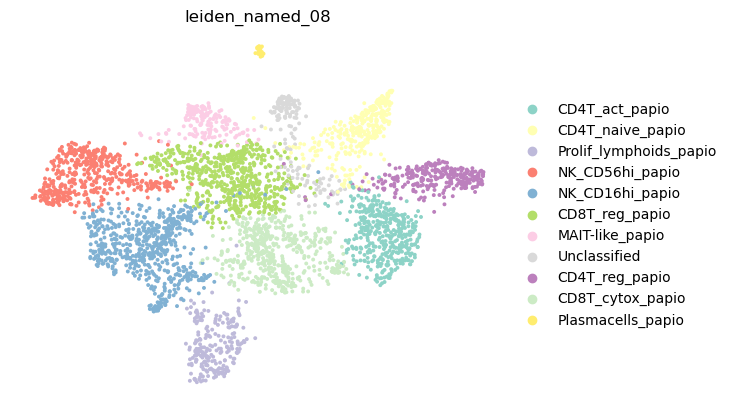

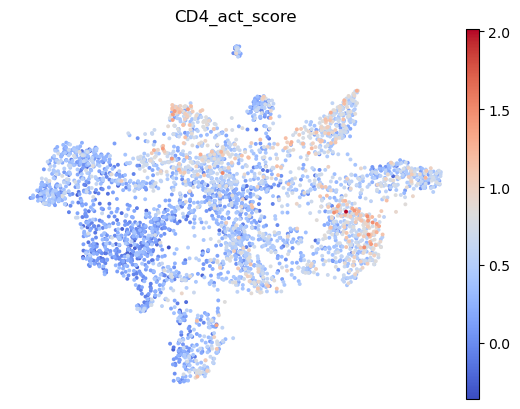

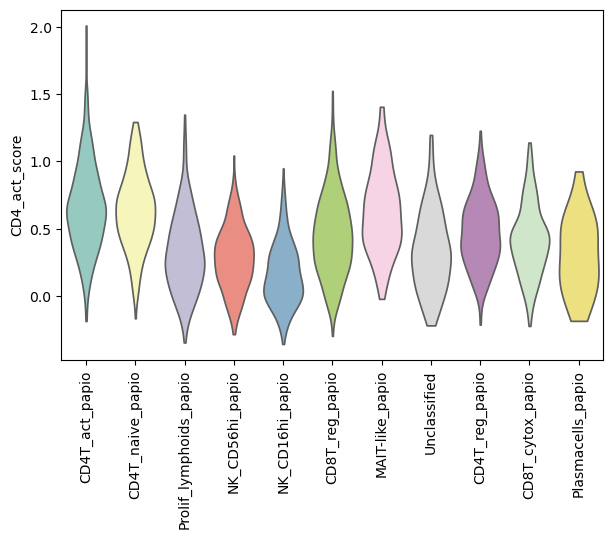

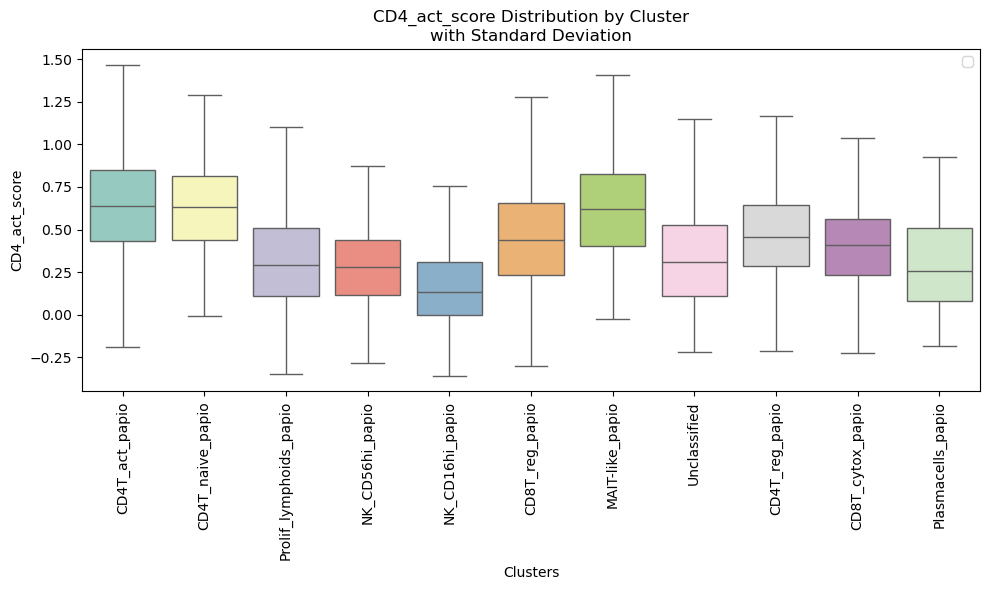

Cluster CD4T_act_papio:
  p-value: 1.25e-54
  FDR-corrected p: 1.37e-53
  Effect size: 0.28
  Significant: True

Cluster Prolif_lymphoids_papio:
  p-value: 1.00e+00
  FDR-corrected p: 1.00e+00
  Effect size: -0.10
  Significant: False

Cluster NK_CD56hi_papio:
  p-value: 1.00e+00
  FDR-corrected p: 1.00e+00
  Effect size: -0.13
  Significant: False

Cluster CD8T_reg_papio:
  p-value: 5.56e-05
  FDR-corrected p: 1.22e-04
  Effect size: 0.06
  Significant: True

Cluster CD4T_naive_papio:
  p-value: 1.65e-40
  FDR-corrected p: 9.08e-40
  Effect size: 0.27
  Significant: True

Cluster MAIT-like_papio:
  p-value: 1.84e-17
  FDR-corrected p: 6.75e-17
  Effect size: 0.24
  Significant: True

Cluster Unclassified:
  p-value: 1.00e+00
  FDR-corrected p: 1.00e+00
  Effect size: -0.08
  Significant: False

Cluster CD4T_reg_papio:
  p-value: 2.36e-05
  FDR-corrected p: 6.49e-05
  Effect size: 0.07
  Significant: True

Cluster CD8T_cytox_papio:
  p-value: 1.37e-01
  FDR-corrected p: 2.52e-01
  Effe

In [19]:
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns 

def analyze_gene_set_scores(
    adata,
    cluster_key='leiden_named_08',
    score_key='CD4_act_score',
    target_cluster='CD4T_act_papio',
    plot=True
):
    """
    Comprehensive analysis of gene set scores across clusters
    
    Parameters:
    adata (AnnData): Input dataset
    cluster_key (str): Column name for cluster labels
    score_key (str): Column name for gene set score to analyze
    target_cluster (str): Specific cluster to compare against others
    plot (bool): Whether to generate visualizations
    
    Returns:
    dict: Statistical results for all clusters
    """
    
    # 1. Statistical testing
    def _test_cluster(adata, cluster_key, score_key, test_cluster):
        target_scores = adata.obs.loc[adata.obs[cluster_key] == test_cluster, score_key]
        other_scores = adata.obs.loc[adata.obs[cluster_key] != test_cluster, score_key]
        
        stat, p = mannwhitneyu(target_scores, other_scores, alternative='greater')
        effect_size = np.median(target_scores) - np.median(other_scores)
        return stat, p, effect_size

    # Test all clusters
    clusters = adata.obs[cluster_key].unique()
    results = {}
    p_values = []
    
    for cluster in clusters:
        stat, p, effect = _test_cluster(adata, cluster_key, score_key, cluster)
        results[cluster] = {
            'statistic': stat,
            'p_value': p,
            'effect_size': effect,
            'n_cells': sum(adata.obs[cluster_key] == cluster)
        }
        p_values.append(p)
    
    # FDR correction
    rejected, corrected_p, _, _ = multipletests(p_values, method='fdr_bh')
    for i, cluster in enumerate(clusters):
        results[cluster]['corrected_p'] = corrected_p[i]
        results[cluster]['significant'] = rejected[i]

        # 2. Visualization with added box plot
    if plot:
        # Existing UMAP and violin plots
        sc.pl.umap(adata, color=cluster_key, frameon=False, show=False)
        sc.pl.umap(adata, color=score_key, cmap='coolwarm', frameon=False, show=False)
        sc.pl.violin(adata, keys=score_key, groupby=cluster_key, rotation=90, stripplot=False, show=False)
        
        # New box plot with standard deviation
        plt.figure(figsize=(10, 6))
        sns.boxplot(
            x=adata.obs[cluster_key],
            y=adata.obs[score_key],
            showfliers=False,
            palette="Set3"
        )
        
        # Calculate and add standard deviation
        cluster_means = adata.obs.groupby(cluster_key)[score_key].mean()
        cluster_stds = adata.obs.groupby(cluster_key)[score_key].std()
        
  #      #plt.errorbar(
  #          x=range(len(cluster_means)),
  #          y=cluster_means,
  #          yerr=cluster_stds,
  #          fmt='none',
  #          ecolor='black',
  #          capsize=5,
  #          label='Standard Deviation'
  #      )
        
        plt.title(f'{score_key} Distribution by Cluster\nwith Standard Deviation')
        plt.xlabel('Clusters')
        plt.ylabel(score_key)
        plt.xticks(rotation=90)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return results



# Example usage -------------------------------------------------
results = analyze_gene_set_scores(
    LYMPHOIDS_harmony,
    score_key='CD4_act_score',  # Change this for different gene sets
    target_cluster='CD4T_act_papio'  # Change this for different clusters
)

# Print formatted results
for cluster, data in results.items():
    print(f"Cluster {cluster}:")
    print(f"  p-value: {data['p_value']:.2e}")
    print(f"  FDR-corrected p: {data['corrected_p']:.2e}")
    print(f"  Effect size: {data['effect_size']:.2f}")
    print(f"  Significant: {data['significant']}\n")



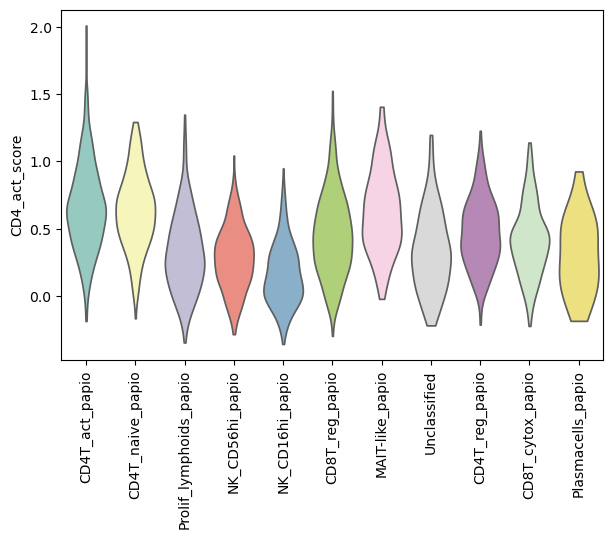

In [20]:
sc.pl.violin(
    LYMPHOIDS_harmony,
    keys="CD4_act_score",
    groupby="leiden_named_08",
    rotation=90,
    stripplot=False
)

# CD4 act

In [16]:
gene_set_CD4_act = ['Papio_anubis_IL7R', 'Papio_anubis_INPP4B', 'Papio_anubis_FKBP5', 'Papio_anubis_ANK3', 
'Papio_anubis_ADAM19', 'Papio_anubis_PCNX1', 'Papio_anubis_THEMIS', 'Papio_anubis_PBX4', 
'Papio_anubis_ERN1', 'Papio_anubis_RBMS1', 'Papio_anubis_ATXN1', 'Papio_anubis_RBPJ', 
'Papio_anubis_SERINC5', 'Papio_anubis_FOXO1', 'Papio_anubis_SLC4A7', 'Papio_anubis_RUNX2', 
'Papio_anubis_ITK', 'Papio_anubis_PHTF2', 'Papio_anubis_LDLRAD4', 'Papio_anubis_PARP8', 
'Papio_anubis_NCK2', 'Papio_anubis_TC2N', 'Papio_anubis_MGAT5', 'Papio_anubis_BCL11B', 
'Papio_anubis_CASK', 'Papio_anubis_ETS1', 'Papio_anubis_IL6ST', 'Papio_anubis_DISC1', 
'Papio_anubis_MDFIC', 'Papio_anubis_AAK1', 'Papio_anubis_CAMK4', 'Papio_anubis_CD2', 
'Papio_anubis_ABCC1', 'Papio_anubis_EML4', 'Papio_anubis_PATJ', 'Papio_anubis_ARHGAP15', 
'Papio_anubis_PDCD4', 'Papio_anubis_IKZF1', 'Papio_anubis_ZBTB16', 'Papio_anubis_CDC14A', 
'Papio_anubis_ZFP36L2', 'Papio_anubis_PAG1', 'Papio_anubis_ZC3HAV1', 'Papio_anubis_PHACTR2']  # Replace with your actual list of genes





Gene set score 'CD4_act_score' calculated using 21 genes.
Valid genes: Papio_anubis_IL7R, Papio_anubis_FKBP5, Papio_anubis_ANK3, Papio_anubis_ADAM19, Papio_anubis_THEMIS, Papio_anubis_RBPJ, Papio_anubis_SLC4A7, Papio_anubis_RUNX2, Papio_anubis_LDLRAD4, Papio_anubis_BCL11B, Papio_anubis_CASK, Papio_anubis_IL6ST, Papio_anubis_DISC1, Papio_anubis_MDFIC, Papio_anubis_CAMK4, Papio_anubis_PATJ, Papio_anubis_ZBTB16, Papio_anubis_CDC14A, Papio_anubis_ZFP36L2, Papio_anubis_PAG1, Papio_anubis_PHACTR2

Gene Scores:
                Gene  Mean Expression  Variance           CV
  Papio_anubis_MDFIC     3.234507e-08  0.999735   30912514.0
 Papio_anubis_BCL11B     2.830194e-08  0.999735   35328588.0
   Papio_anubis_ANK3     2.425881e-08  0.999735   41216680.0
Papio_anubis_PHACTR2     1.415097e-08  0.999735   70657176.0
 Papio_anubis_CDC14A     1.212940e-08  0.999735   82433368.0
  Papio_anubis_FKBP5     8.086269e-09  0.999735  123650048.0
 Papio_anubis_SLC4A7    -4.548526e-09  0.999735 -219822304.0
  

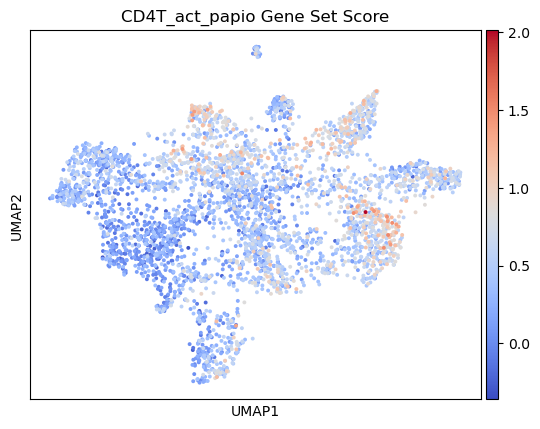

In [17]:
# Calculate score for CD4 activated gene set
valid_cd4_act_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD4_act, 'CD4_act_score')

# Visualize the results
if valid_cd4_act_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD4_act_score', cmap='coolwarm', wspace=0.1, ncols=5, title='CD4T_act_papio Gene Set Score')

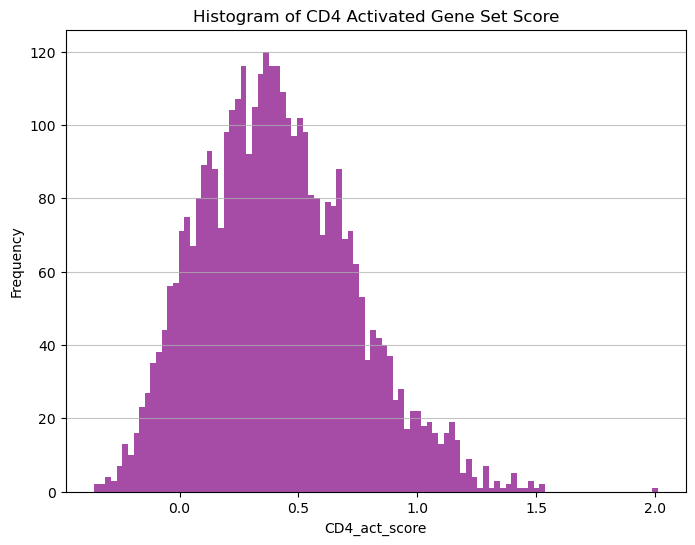

In [18]:
import matplotlib.pyplot as plt

# Extract the CD4 activated gene set score
cd4_scores = LYMPHOIDS_harmony.obs['CD4_act_score']

# Plot the histogram
plt.figure(figsize=(8, 6))
plt.hist(cd4_scores, bins=100, color='purple', alpha=0.7)
plt.title('Histogram of CD4 Activated Gene Set Score')
plt.xlabel('CD4_act_score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


# CD4 naive

In [21]:
gene_set_CD4_naive = ["Papio_anubis_IL7R", "Papio_anubis_SERINC5", "Papio_anubis_PRKCA", "Papio_anubis_ANK3", "Papio_anubis_LEF1", "Papio_anubis_INPP4B", "Papio_anubis_CDC14A", "Papio_anubis_RIPOR2", "Papio_anubis_THOC3", "Papio_anubis_PDE3B", "Papio_anubis_AC139720.1", "Papio_anubis_LDLRAD4", "Papio_anubis_CAMK4", "Papio_anubis_SMCHD1", "Papio_anubis_FOXP1", "Papio_anubis_ARHGAP15", "Papio_anubis_TCF7", "Papio_anubis_TTC39C", "Papio_anubis_BACH2", "Papio_anubis_BCL11B", "Papio_anubis_PVT1", "Papio_anubis_TSHZ2", "Papio_anubis_TXNIP", "Papio_anubis_PAG1", "Papio_anubis_ITK", "Papio_anubis_P2RY8", "Papio_anubis_CSGALNACT1", "Papio_anubis_MAML2", "Papio_anubis_STK38", "Papio_anubis_AC119396.1", "Papio_anubis_PATJ", "Papio_anubis_GNAQ", "Papio_anubis_SORL1", "Papio_anubis_RCAN3", "Papio_anubis_DOCK9", "Papio_anubis_PCAT1", "Papio_anubis_MGAT5", "Papio_anubis_FHIT", "Papio_anubis_SARAF", "Papio_anubis_MCUB", "Papio_anubis_SESN3", "Papio_anubis_TXK", "Papio_anubis_RASA3", "Papio_anubis_NDFIP1", "Papio_anubis_TNFSF8", "Papio_anubis_NCK2", "Papio_anubis_FAAH2", "Papio_anubis_TESPA1", "Papio_anubis_RASGRF2", "Papio_anubis_ESYT2", "Papio_anubis_CNST", "Papio_anubis_AC010260.1", "Papio_anubis_KLF2", "Papio_anubis_ETS1", "Papio_anubis_CASK", "Papio_anubis_TMEM131L", "Papio_anubis_FKBP5", "Papio_anubis_AAK1", "Papio_anubis_CYTH1", "Papio_anubis_PIK3IP1", "Papio_anubis_ETV6", "Papio_anubis_OXNAD1", "Papio_anubis_PSMA1", "Papio_anubis_DGKA", "Papio_anubis_RASSF3", "Papio_anubis_ELMO1", "Papio_anubis_RORA", "Papio_anubis_BCL2", "Papio_anubis_DIP2B", "Papio_anubis_RBMS1", "Papio_anubis_RASGRP2", "Papio_anubis_IKZF1", "Papio_anubis_SAMHD1", "Papio_anubis_SELL", "Papio_anubis_AFF1", "Papio_anubis_LEPROTL1", "Papio_anubis_PHACTR2", "Papio_anubis_ZC3HAV1", "Papio_anubis_MGAT4A", "Papio_anubis_CD6", "Papio_anubis_EPHA4", "Papio_anubis_PACS1", "Papio_anubis_DUSP16", "Papio_anubis_ZEB1", "Papio_anubis_STAT5B", "Papio_anubis_FAM19A1", "Papio_anubis_TRABD2A", "Papio_anubis_PRKCA-AS1", "Papio_anubis_BIRC3", "Papio_anubis_GPHN", "Papio_anubis_SYNE2", "Papio_anubis_BTBD11", "Papio_anubis_HIVEP2", "Papio_anubis_RUNX2", "Papio_anubis_AP001011.1", "Papio_anubis_ABCC1", "Papio_anubis_ARID5B", "Papio_anubis_SPOCK2", "Papio_anubis_SLCO3A1", "Papio_anubis_IMMP2L"]

Gene set score 'CD4_naive_score' calculated using 35 genes.
Valid genes: Papio_anubis_IL7R, Papio_anubis_ANK3, Papio_anubis_LEF1, Papio_anubis_CDC14A, Papio_anubis_THOC3, Papio_anubis_PDE3B, Papio_anubis_LDLRAD4, Papio_anubis_CAMK4, Papio_anubis_FOXP1, Papio_anubis_TCF7, Papio_anubis_BACH2, Papio_anubis_BCL11B, Papio_anubis_TSHZ2, Papio_anubis_PAG1, Papio_anubis_PATJ, Papio_anubis_GNAQ, Papio_anubis_FHIT, Papio_anubis_SESN3, Papio_anubis_RASGRF2, Papio_anubis_CASK, Papio_anubis_FKBP5, Papio_anubis_PIK3IP1, Papio_anubis_PSMA1, Papio_anubis_DGKA, Papio_anubis_RASSF3, Papio_anubis_RASGRP2, Papio_anubis_SELL, Papio_anubis_PHACTR2, Papio_anubis_DUSP16, Papio_anubis_GPHN, Papio_anubis_SYNE2, Papio_anubis_RUNX2, Papio_anubis_ARID5B, Papio_anubis_SLCO3A1, Papio_anubis_IMMP2L

Gene Scores:
                Gene  Mean Expression  Variance            CV
  Papio_anubis_PSMA1     5.256075e-08  0.999735  1.902309e+07
   Papio_anubis_GNAQ     3.840978e-08  0.999735  2.603159e+07
  Papio_anubis_TSHZ2  

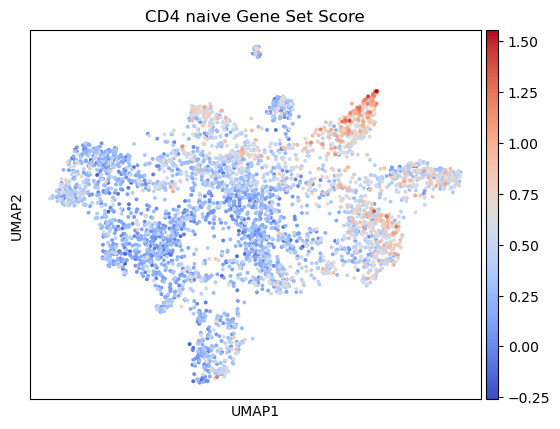

In [22]:
valid_CD4_naive_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD4_naive, 'CD4_naive_score')

# Visualize the results if valid genes were found
if valid_CD4_naive_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD4_naive_score', cmap='coolwarm', wspace=0.1, ncols=5, title='CD4 naive Gene Set Score')


# CD4 reg 

In [23]:
gene_set_CD4_reg = ["Papio_anubis_IKZF2", "Papio_anubis_RTKN2", "Papio_anubis_USP15", "Papio_anubis_C15orf53", "Papio_anubis_PHACTR2", "Papio_anubis_LDLRAD4", "Papio_anubis_CASK", "Papio_anubis_FOXO1", "Papio_anubis_PLCL1", "Papio_anubis_TBC1D4", "Papio_anubis_SKAP1", "Papio_anubis_IL2RA", "Papio_anubis_ARID5B", "Papio_anubis_GPHN", "Papio_anubis_SAMHD1", "Papio_anubis_PVT1", "Papio_anubis_FAM19A2", "Papio_anubis_AC013652.1", "Papio_anubis_PACS1", "Papio_anubis_PHTF2", "Papio_anubis_STAM", "Papio_anubis_MAP3K5", "Papio_anubis_SYNE2", "Papio_anubis_ABCC1", "Papio_anubis_AL357793.1", "Papio_anubis_GLCCI1", "Papio_anubis_TOX", "Papio_anubis_DUSP16", "Papio_anubis_CTLA4", "Papio_anubis_SGMS1", "Papio_anubis_ITK", "Papio_anubis_UGP2", "Papio_anubis_MAST4", "Papio_anubis_SLA", "Papio_anubis_TNIK", "Papio_anubis_PELI1", "Papio_anubis_NCK2", "Papio_anubis_SLAMF1", "Papio_anubis_NEAT1", "Papio_anubis_EPB41", "Papio_anubis_ETS1", "Papio_anubis_LEF1", "Papio_anubis_LINC00426", "Papio_anubis_TULP4", "Papio_anubis_ENTPD1", "Papio_anubis_MIR4435-2HG", "Papio_anubis_PDE3B", "Papio_anubis_FAM129A", "Papio_anubis_BCL11B", "Papio_anubis_GNAQ", "Papio_anubis_RUNX1", "Papio_anubis_BACH1", "Papio_anubis_TPTEP2-CSNK1E", "Papio_anubis_HNRNPLL", "Papio_anubis_JAKMIP1", "Papio_anubis_TLK1", "Papio_anubis_IL10RA", "Papio_anubis_SMAP2", "Papio_anubis_TTN", "Papio_anubis_MAML2", "Papio_anubis_CHST11", "Papio_anubis_ATXN7L1", "Papio_anubis_CNST", "Papio_anubis_TSPAN5", "Papio_anubis_SMCHD1", "Papio_anubis_AL357060.1", "Papio_anubis_CAMK4", "Papio_anubis_RCAN3", "Papio_anubis_BIRC3", "Papio_anubis_RCSD1", "Papio_anubis_SPOCK2", "Papio_anubis_DGKA", "Papio_anubis_SIRPG", "Papio_anubis_MAP3K1", "Papio_anubis_ZNF831", "Papio_anubis_DIP2B", "Papio_anubis_SESN3", "Papio_anubis_IL6ST", "Papio_anubis_STAT5B", "Papio_anubis_BATF", "Papio_anubis_TIAM1", "Papio_anubis_GLG1", "Papio_anubis_AFF1", "Papio_anubis_ANTXR2", "Papio_anubis_ICA1", "Papio_anubis_UBASH3B", "Papio_anubis_IL6R", "Papio_anubis_AAK1", "Papio_anubis_PTPRJ", "Papio_anubis_THEM4", "Papio_anubis_SLC7A6", "Papio_anubis_SLC12A6", "Papio_anubis_ICOS", "Papio_anubis_ENTPD1-AS1", "Papio_anubis_ZBTB38", "Papio_anubis_SNX9", "Papio_anubis_FP671120.1", "Papio_anubis_PBX4", "Papio_anubis_CD44", "Papio_anubis_NABP1"]

Gene set score 'CD4_reg_score' calculated using 38 genes.
Valid genes: Papio_anubis_IKZF2, Papio_anubis_RTKN2, Papio_anubis_PHACTR2, Papio_anubis_LDLRAD4, Papio_anubis_CASK, Papio_anubis_PLCL1, Papio_anubis_TBC1D4, Papio_anubis_IL2RA, Papio_anubis_ARID5B, Papio_anubis_GPHN, Papio_anubis_STAM, Papio_anubis_MAP3K5, Papio_anubis_SYNE2, Papio_anubis_GLCCI1, Papio_anubis_DUSP16, Papio_anubis_MAST4, Papio_anubis_PELI1, Papio_anubis_SLAMF1, Papio_anubis_LEF1, Papio_anubis_TULP4, Papio_anubis_ENTPD1, Papio_anubis_PDE3B, Papio_anubis_BCL11B, Papio_anubis_GNAQ, Papio_anubis_RUNX1, Papio_anubis_BACH1, Papio_anubis_TTN, Papio_anubis_ATXN7L1, Papio_anubis_TSPAN5, Papio_anubis_CAMK4, Papio_anubis_DGKA, Papio_anubis_ZNF831, Papio_anubis_SESN3, Papio_anubis_IL6ST, Papio_anubis_ANTXR2, Papio_anubis_UBASH3B, Papio_anubis_IL6R, Papio_anubis_ICOS

Gene Scores:
                Gene  Mean Expression  Variance            CV
  Papio_anubis_IL2RA     5.862545e-08  0.999735  1.705518e+07
   Papio_anubis_GNAQ   

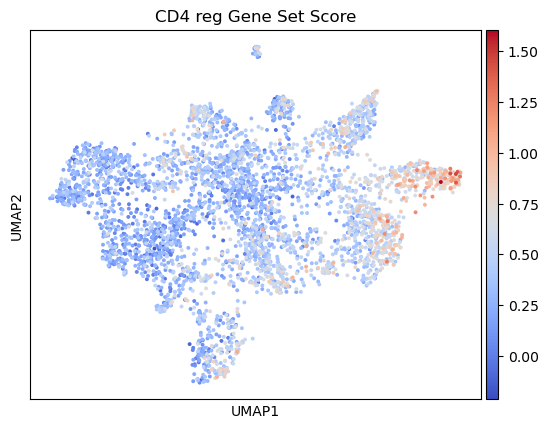

In [24]:
valid_CD4_reg_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD4_reg, 'CD4_reg_score')

# Visualize the results if valid genes were found
if valid_CD4_reg_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD4_reg_score', cmap='coolwarm', wspace=0.1, ncols=5, title='CD4 reg Gene Set Score')


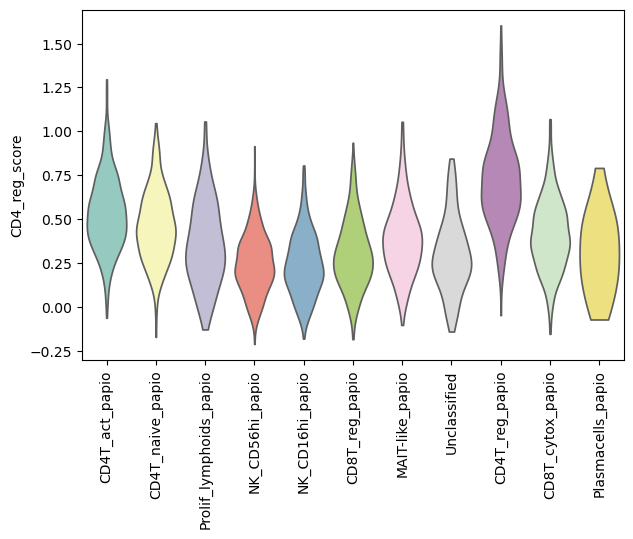

In [25]:
sc.pl.violin(
    LYMPHOIDS_harmony,
    keys="CD4_reg_score",
    groupby="leiden_named_08",
    rotation=90,
    stripplot=False
)

# CD 8 cytotoxic 

In [26]:
gene_set_CD8_cytotox = ["Papio_anubis_ZEB2", "Papio_anubis_RAP1GAP2", "Papio_anubis_THEMIS", "Papio_anubis_SYNE1", "Papio_anubis_TGFBR3", "Papio_anubis_RIPOR2", "Papio_anubis_A2M", "Papio_anubis_PZP", "Papio_anubis_AC243829.2", "Papio_anubis_SYNE2", "Papio_anubis_MYO1F", "Papio_anubis_RABGAP1L", "Papio_anubis_SAMD3", "Papio_anubis_GNG2", "Papio_anubis_GNLY", "Papio_anubis_FAM19A1", "Papio_anubis_HIVEP3", "Papio_anubis_ADGRE5", "Papio_anubis_PTPRC", "Papio_anubis_PRKCB", "Papio_anubis_GRAP2", "Papio_anubis_KLRD1", "Papio_anubis_ITGAL", "Papio_anubis_PRKCQ", "Papio_anubis_NLRC5", "Papio_anubis_MACF1", "Papio_anubis_C1orf21", "Papio_anubis_GZMH", "Papio_anubis_TRG-AS1", "Papio_anubis_KLRG1", "Papio_anubis_FAM49B", "Papio_anubis_RNF213", "Papio_anubis_RAP1B", "Papio_anubis_B2M", "Papio_anubis_LINC00861", "Papio_anubis_ARHGEF3", "Papio_anubis_PICALM", "Papio_anubis_RAPGEF1", "Papio_anubis_MYBL1", "Papio_anubis_STK10", "Papio_anubis_AC022075.1", "Papio_anubis_TRGC2", "Papio_anubis_MIR4435-2HG", "Papio_anubis_HLA-C", "Papio_anubis_CYTH1", "Papio_anubis_BCL2", "Papio_anubis_EIF4G3", "Papio_anubis_CYFIP2", "Papio_anubis_LINC02384", "Papio_anubis_BIN2", "Papio_anubis_MBP", "Papio_anubis_AGAP1", "Papio_anubis_PCED1B", "Papio_anubis_CARD11", "Papio_anubis_TNIK", "Papio_anubis_NFATC2", "Papio_anubis_CX3CR1", "Papio_anubis_PYHIN1", "Papio_anubis_VCL", "Papio_anubis_SRPK2", "Papio_anubis_NCALD", "Papio_anubis_PPP2R2B", "Papio_anubis_C12orf75", "Papio_anubis_INPP4A", "Papio_anubis_NKG7", "Papio_anubis_CTSC", "Papio_anubis_SETBP1", "Papio_anubis_PPP3CC", "Papio_anubis_KLF2", "Papio_anubis_PTPRJ", "Papio_anubis_NFATC3", "Papio_anubis_FNDC3B", "Papio_anubis_DIAPH1", "Papio_anubis_LCP1", "Papio_anubis_HLA-B", "Papio_anubis_P2RY8", "Papio_anubis_AGPAT4", "Papio_anubis_ARHGAP26", "Papio_anubis_PRKCH", "Papio_anubis_ITGB1", "Papio_anubis_IQGAP2", "Papio_anubis_YES1", "Papio_anubis_CCDC88C", "Papio_anubis_PRF1", "Papio_anubis_PRR5L", "Papio_anubis_ARL4C", "Papio_anubis_GAB3", "Papio_anubis_HLA-E", "Papio_anubis_STK17B", "Papio_anubis_ERBIN", "Papio_anubis_FLNA", "Papio_anubis_AC116366.3", "Papio_anubis_ATP2B4", "Papio_anubis_PPP2R5C", "Papio_anubis_DOCK11", "Papio_anubis_SSBP3", "Papio_anubis_RASSF1", "Papio_anubis_JAZF1", "Papio_anubis_TBX21", "Papio_anubis_ADGRG5"]

Gene set score 'CD8_cytotox_score' calculated using 19 genes.
Valid genes: Papio_anubis_ZEB2, Papio_anubis_RAP1GAP2, Papio_anubis_THEMIS, Papio_anubis_TGFBR3, Papio_anubis_SYNE2, Papio_anubis_SAMD3, Papio_anubis_GNLY, Papio_anubis_HIVEP3, Papio_anubis_KLRD1, Papio_anubis_C1orf21, Papio_anubis_AGAP1, Papio_anubis_SRPK2, Papio_anubis_NCALD, Papio_anubis_PPP2R2B, Papio_anubis_CTSC, Papio_anubis_SETBP1, Papio_anubis_AGPAT4, Papio_anubis_PRR5L, Papio_anubis_SSBP3

Gene Scores:
                 Gene  Mean Expression  Variance           CV
  Papio_anubis_SETBP1     4.750683e-08  0.999735   21046818.0
   Papio_anubis_KLRD1     4.043134e-08  0.999735   24730012.0
  Papio_anubis_TGFBR3     2.830194e-08  0.999735   35328584.0
 Papio_anubis_PPP2R2B     2.223724e-08  0.999735   44963652.0
   Papio_anubis_SRPK2     2.072106e-08  0.999735   48253672.0
   Papio_anubis_PRR5L     2.021567e-08  0.999735   49460020.0
   Papio_anubis_SYNE2     1.819410e-08  0.999735   54955576.0
   Papio_anubis_NCALD     1

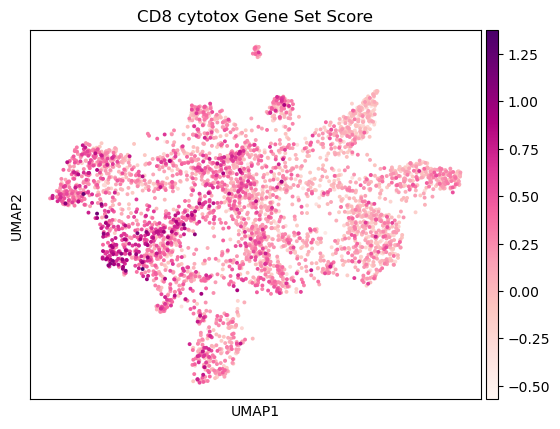

In [27]:
valid_CD8_cytotox_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD8_cytotox, 'CD8_cytotox_score')

# Visualize the results if valid genes were found
if valid_CD8_cytotox_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD8_cytotox_score', cmap='RdPu', wspace=0.1, ncols=5, title='CD8 cytotox Gene Set Score')

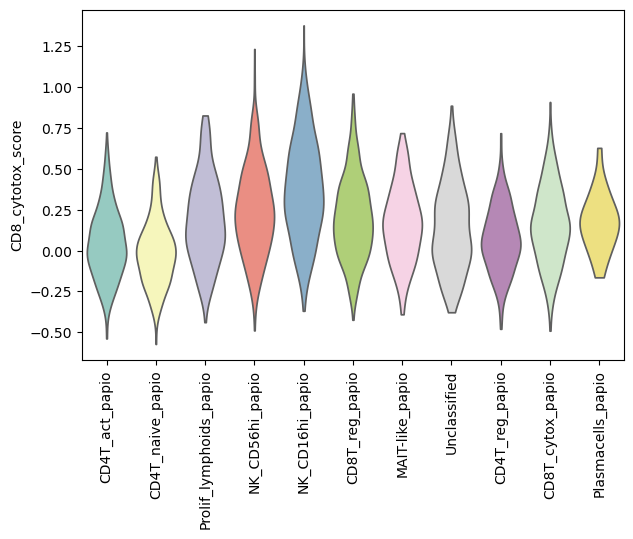

In [28]:
sc.pl.violin(
    LYMPHOIDS_harmony,
    keys="CD8_cytotox_score",
    groupby="leiden_named_08",
    rotation=90,
    stripplot=False
)

# CD 8 em

In [29]:
gene_set_CD8_em = ["Papio_anubis_AC022075.1", "Papio_anubis_PARP8", "Papio_anubis_CAMK4", "Papio_anubis_IL7R", "Papio_anubis_TC2N", "Papio_anubis_AKT3", "Papio_anubis_CASK", "Papio_anubis_PATJ", "Papio_anubis_PCNX1", "Papio_anubis_PDE3B", "Papio_anubis_SERINC5", "Papio_anubis_MVB12B", "Papio_anubis_NELL2", "Papio_anubis_NR3C2", "Papio_anubis_DISC1", "Papio_anubis_FAM129A", "Papio_anubis_CD96", "Papio_anubis_SCML4", "Papio_anubis_EMB", "Papio_anubis_OXNAD1", "Papio_anubis_RBMS1", "Papio_anubis_MALAT1", "Papio_anubis_KLRC1", "Papio_anubis_LINC01934", "Papio_anubis_TXNIP", "Papio_anubis_KLRC4-KLRK1", "Papio_anubis_RUNX2", "Papio_anubis_CDC14A", "Papio_anubis_JAML", "Papio_anubis_LEF1", "Papio_anubis_KAT6B", "Papio_anubis_BACH2", "Papio_anubis_MAML2", "Papio_anubis_FKBP5", "Papio_anubis_MDFIC", "Papio_anubis_PRKCA", "Papio_anubis_INPP4B", "Papio_anubis_ZBTB20", "Papio_anubis_ARHGAP15", "Papio_anubis_PCNX2", "Papio_anubis_KIAA1551", "Papio_anubis_RBPJ", "Papio_anubis_THEMIS", "Papio_anubis_NAP1L4", "Papio_anubis_RASGRF2", "Papio_anubis_TRERF1", "Papio_anubis_SOS1", "Papio_anubis_CD8B", "Papio_anubis_SEMA4D", "Papio_anubis_ITGA1", "Papio_anubis_PDE7A", "Papio_anubis_EML4", "Papio_anubis_ATP8A1", "Papio_anubis_ABCC1", "Papio_anubis_IFNG-AS1", "Papio_anubis_GPR155", "Papio_anubis_FYB1", "Papio_anubis_PBX4", "Papio_anubis_CD44", "Papio_anubis_BCL11B", "Papio_anubis_NFIA", "Papio_anubis_TNFSF8", "Papio_anubis_PSMA1", "Papio_anubis_BTG1", "Papio_anubis_RCSD1", "Papio_anubis_CASS4", "Papio_anubis_DOCK10", "Papio_anubis_LINC02446", "Papio_anubis_DOCK8", "Papio_anubis_MPP7", "Papio_anubis_PCAT1", "Papio_anubis_IMMP2L", "Papio_anubis_AC006369.1", "Papio_anubis_ITK", "Papio_anubis_TNRC6B", "Papio_anubis_ZFP36L2", "Papio_anubis_DOCK5", "Papio_anubis_DAPK2", "Papio_anubis_LINC01871", "Papio_anubis_TNRC6C", "Papio_anubis_MGAT5", "Papio_anubis_CCSER2", "Papio_anubis_SARAF", "Papio_anubis_FBXO32", "Papio_anubis_LINC00623", "Papio_anubis_OGT", "Papio_anubis_CD2", "Papio_anubis_FTX", "Papio_anubis_IL6ST", "Papio_anubis_AC010609.1", "Papio_anubis_SMAP2", "Papio_anubis_RCAN3", "Papio_anubis_PIK3IP1", "Papio_anubis_PHC3", "Papio_anubis_ZC3HAV1", "Papio_anubis_ZNF609", "Papio_anubis_LEPROTL1", "Papio_anubis_SYNRG", "Papio_anubis_TCF7", "Papio_anubis_SLC4A7"]

Gene set score 'CD8_em_score' calculated using 39 genes.
Valid genes: Papio_anubis_CAMK4, Papio_anubis_IL7R, Papio_anubis_CASK, Papio_anubis_PATJ, Papio_anubis_PDE3B, Papio_anubis_NR3C2, Papio_anubis_DISC1, Papio_anubis_CD96, Papio_anubis_SCML4, Papio_anubis_KLRC1, Papio_anubis_RUNX2, Papio_anubis_CDC14A, Papio_anubis_JAML, Papio_anubis_LEF1, Papio_anubis_BACH2, Papio_anubis_FKBP5, Papio_anubis_MDFIC, Papio_anubis_PCNX2, Papio_anubis_RBPJ, Papio_anubis_THEMIS, Papio_anubis_RASGRF2, Papio_anubis_TRERF1, Papio_anubis_SOS1, Papio_anubis_ITGA1, Papio_anubis_GPR155, Papio_anubis_BCL11B, Papio_anubis_NFIA, Papio_anubis_PSMA1, Papio_anubis_BTG1, Papio_anubis_CASS4, Papio_anubis_MPP7, Papio_anubis_IMMP2L, Papio_anubis_ZFP36L2, Papio_anubis_DOCK5, Papio_anubis_DAPK2, Papio_anubis_IL6ST, Papio_anubis_PIK3IP1, Papio_anubis_TCF7, Papio_anubis_SLC4A7

Gene Scores:
                Gene  Mean Expression  Variance            CV
  Papio_anubis_KLRC1     5.660388e-08  0.999735  1.766429e+07
  Papio_anub

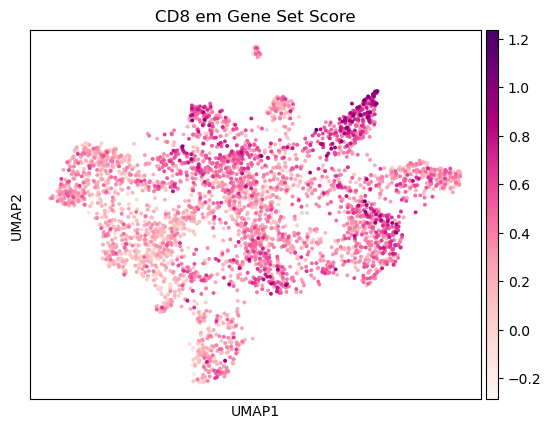

In [30]:
valid_CD8_em_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD8_em, 'CD8_em_score')

# Visualize the results if valid genes were found
if valid_CD8_em_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD8_em_score', cmap='RdPu', wspace=0.1, ncols=5, title='CD8 em Gene Set Score')

# CD8 te 

In [31]:
gene_set_CD8_te = ["Papio_anubis_AOAH", "Papio_anubis_PPP2R5C", "Papio_anubis_FYN", "Papio_anubis_CNOT6L", "Papio_anubis_PDE3B", "Papio_anubis_CEMIP2", "Papio_anubis_CAMK4", "Papio_anubis_AC016831.7", "Papio_anubis_PTPRC", "Papio_anubis_SYTL3", "Papio_anubis_ATXN1", "Papio_anubis_SMCHD1", "Papio_anubis_ATP8A1", "Papio_anubis_PITPNC1", "Papio_anubis_CBLB", "Papio_anubis_LYST", "Papio_anubis_P2RY8", "Papio_anubis_AKNA", "Papio_anubis_FOXP1", "Papio_anubis_PPP1R16B", "Papio_anubis_PARP8", "Papio_anubis_CRYBG1", "Papio_anubis_PRKCH", "Papio_anubis_IQGAP2", "Papio_anubis_DUSP2", "Papio_anubis_ETS1", "Papio_anubis_RUNX3", "Papio_anubis_FAM129A", "Papio_anubis_DTHD1", "Papio_anubis_CDC42SE2", "Papio_anubis_EML4", "Papio_anubis_BCL11B", "Papio_anubis_MVB12B", "Papio_anubis_KLF12", "Papio_anubis_SAMD3", "Papio_anubis_ITGA4", "Papio_anubis_ATXN7L1", "Papio_anubis_PIK3R1", "Papio_anubis_ARID5B", "Papio_anubis_EPB41", "Papio_anubis_TC2N", "Papio_anubis_SARAF", "Papio_anubis_FOXO1", "Papio_anubis_PHACTR2", "Papio_anubis_LITAF", "Papio_anubis_SYNE1", "Papio_anubis_WIPF1", "Papio_anubis_RASA3", "Papio_anubis_WNK1", "Papio_anubis_BICDL1", "Papio_anubis_ZEB2", "Papio_anubis_PIP4K2A", "Papio_anubis_RNF19A", "Papio_anubis_SLC38A1", "Papio_anubis_A2M", "Papio_anubis_RABGAP1L", "Papio_anubis_GALNT11", "Papio_anubis_STAT4", "Papio_anubis_MAML2", "Papio_anubis_TPRG1", "Papio_anubis_PZP", "Papio_anubis_NLRC5", "Papio_anubis_NIN", "Papio_anubis_TRERF1", "Papio_anubis_TNRC6B", "Papio_anubis_ITK", "Papio_anubis_PCAT1", "Papio_anubis_TNIP3", "Papio_anubis_JAKMIP1", "Papio_anubis_ZFP36L2", "Papio_anubis_STK38", "Papio_anubis_PYHIN1", "Papio_anubis_AL357060.1", "Papio_anubis_RAPGEF1", "Papio_anubis_CD84", "Papio_anubis_CREM", "Papio_anubis_THEMIS", "Papio_anubis_SIK3", "Papio_anubis_TGFBR3", "Papio_anubis_CMIP", "Papio_anubis_EMB", "Papio_anubis_ZNF831", "Papio_anubis_CCSER2", "Papio_anubis_TMEM181", "Papio_anubis_DDX5", "Papio_anubis_ARAP2", "Papio_anubis_PRKCQ", "Papio_anubis_TRPS1", "Papio_anubis_MPP7", "Papio_anubis_SGCD", "Papio_anubis_PSMA1", "Papio_anubis_MCOLN2", "Papio_anubis_MCUB", "Papio_anubis_NLRP1", "Papio_anubis_MRPL1", "Papio_anubis_PRKCB", "Papio_anubis_SAMSN1", "Papio_anubis_RNF125", "Papio_anubis_GTDC1", "Papio_anubis_STK4"]

Gene set score 'CD8_te_score' calculated using 28 genes.
Valid genes: Papio_anubis_AOAH, Papio_anubis_PDE3B, Papio_anubis_CEMIP2, Papio_anubis_CAMK4, Papio_anubis_SYTL3, Papio_anubis_FOXP1, Papio_anubis_DTHD1, Papio_anubis_BCL11B, Papio_anubis_SAMD3, Papio_anubis_ATXN7L1, Papio_anubis_ARID5B, Papio_anubis_PHACTR2, Papio_anubis_LITAF, Papio_anubis_BICDL1, Papio_anubis_ZEB2, Papio_anubis_RNF19A, Papio_anubis_STAT4, Papio_anubis_TRERF1, Papio_anubis_TNIP3, Papio_anubis_ZFP36L2, Papio_anubis_CREM, Papio_anubis_THEMIS, Papio_anubis_TGFBR3, Papio_anubis_CMIP, Papio_anubis_ZNF831, Papio_anubis_TRPS1, Papio_anubis_MPP7, Papio_anubis_PSMA1

Gene Scores:
                Gene  Mean Expression  Variance           CV
  Papio_anubis_PSMA1     5.256075e-08  0.999735   19023086.0
  Papio_anubis_LITAF     2.880733e-08  0.999735   34708784.0
 Papio_anubis_BCL11B     2.830194e-08  0.999735   35328588.0
 Papio_anubis_ZNF831     2.830194e-08  0.999735   35328584.0
 Papio_anubis_TGFBR3     2.830194e-08  0.9

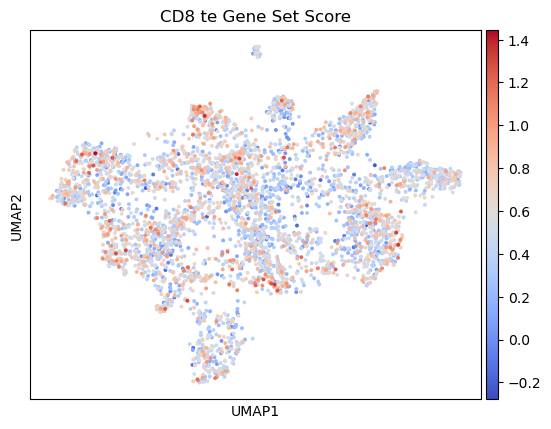

In [32]:
valid_CD8_te_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD8_te, 'CD8_te_score')

# Visualize the results if valid genes were found
if valid_CD8_te_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD8_te_score', cmap='coolwarm', wspace=0.1, ncols=5, title='CD8 te Gene Set Score')

# CD8 te IFNGhi

In [33]:
gene_set_CD8_teIFNGhi = ["Papio_anubis_CCL4", "Papio_anubis_CCL3", "Papio_anubis_RNF19A", "Papio_anubis_CBLB", "Papio_anubis_RHOH", "Papio_anubis_GBP2", "Papio_anubis_GNG2", "Papio_anubis_NFKBID", "Papio_anubis_RAB8B", "Papio_anubis_DUSP2", "Papio_anubis_REL", "Papio_anubis_IFNG", "Papio_anubis_NR4A3", "Papio_anubis_PTPRC", "Papio_anubis_SLA", "Papio_anubis_SYTL3", "Papio_anubis_CRTAM", "Papio_anubis_YES1", "Papio_anubis_RILPL2", "Papio_anubis_NR4A2", "Papio_anubis_FYN", "Papio_anubis_CD69", "Papio_anubis_MIR155HG", "Papio_anubis_NFKBIA", "Papio_anubis_HLA-B", "Papio_anubis_THEMIS", "Papio_anubis_SP140", "Papio_anubis_TNF", "Papio_anubis_PRKCH", "Papio_anubis_HIF1A", "Papio_anubis_LYST", "Papio_anubis_AC022075.1", "Papio_anubis_ARID5B", "Papio_anubis_CCL5", "Papio_anubis_MAP3K8", "Papio_anubis_JARID2", "Papio_anubis_TNFAIP3", "Papio_anubis_DTHD1", "Papio_anubis_FNBP1", "Papio_anubis_B2M", "Papio_anubis_HNRNPC", "Papio_anubis_RAB27A", "Papio_anubis_ZEB2", "Papio_anubis_NR4A1", "Papio_anubis_HLA-C", "Papio_anubis_XCL2", "Papio_anubis_STAT4", "Papio_anubis_IPCEF1", "Papio_anubis_RASGEF1B", "Papio_anubis_PTPN22", "Papio_anubis_KLRD1", "Papio_anubis_IKZF3", "Papio_anubis_IGF2R", "Papio_anubis_HLA-E", "Papio_anubis_HIVEP2", "Papio_anubis_CAPZA1", "Papio_anubis_RAB11A", "Papio_anubis_KMT2E", "Papio_anubis_TAGAP", "Papio_anubis_TG", "Papio_anubis_ADGRE5", "Papio_anubis_AC243829.2", "Papio_anubis_NFKB1", "Papio_anubis_RAP1A", "Papio_anubis_OSBPL3", "Papio_anubis_GABPB1", "Papio_anubis_IRF8", "Papio_anubis_TANK", "Papio_anubis_GADD45B", "Papio_anubis_GFOD1", "Papio_anubis_TOX", "Papio_anubis_NKG7", "Papio_anubis_CEMIP2", "Papio_anubis_SERPINB9", "Papio_anubis_BAZ1A", "Papio_anubis_MCOLN2", "Papio_anubis_OPRM1", "Papio_anubis_GZMB", "Papio_anubis_PTPN7", "Papio_anubis_STK17B", "Papio_anubis_ID2", "Papio_anubis_FASLG", "Papio_anubis_SDCBP", "Papio_anubis_ITGA4", "Papio_anubis_CD8A", "Papio_anubis_HLA-A", "Papio_anubis_PYHIN1", "Papio_anubis_ARPC2", "Papio_anubis_TNFRSF1B", "Papio_anubis_NFATC2", "Papio_anubis_TRAF1", "Papio_anubis_PTGER4", "Papio_anubis_TRGC2", "Papio_anubis_ITPKB", "Papio_anubis_SRGN", "Papio_anubis_NAMPT", "Papio_anubis_IL21R", "Papio_anubis_FBXO11", "Papio_anubis_KLF6", "Papio_anubis_FOSL2"]

Gene set score 'CD8_teIFNGhi_score' calculated using 28 genes.
Valid genes: Papio_anubis_RNF19A, Papio_anubis_NFKBID, Papio_anubis_REL, Papio_anubis_IFNG, Papio_anubis_NR4A3, Papio_anubis_SYTL3, Papio_anubis_CRTAM, Papio_anubis_RILPL2, Papio_anubis_NR4A2, Papio_anubis_NFKBIA, Papio_anubis_THEMIS, Papio_anubis_ARID5B, Papio_anubis_MAP3K8, Papio_anubis_JARID2, Papio_anubis_DTHD1, Papio_anubis_ZEB2, Papio_anubis_NR4A1, Papio_anubis_STAT4, Papio_anubis_KLRD1, Papio_anubis_IGF2R, Papio_anubis_TAGAP, Papio_anubis_OSBPL3, Papio_anubis_IRF8, Papio_anubis_GFOD1, Papio_anubis_CEMIP2, Papio_anubis_OPRM1, Papio_anubis_GZMB, Papio_anubis_TNFRSF1B

Gene Scores:
                 Gene  Mean Expression  Variance            CV
   Papio_anubis_CRTAM     4.144213e-08  0.999735  2.412684e+07
   Papio_anubis_KLRD1     4.043134e-08  0.999735  2.473001e+07
     Papio_anubis_REL     3.007081e-08  0.999735  3.325043e+07
   Papio_anubis_SYTL3     2.830194e-08  0.999735  3.532858e+07
    Papio_anubis_GZMB     2.5

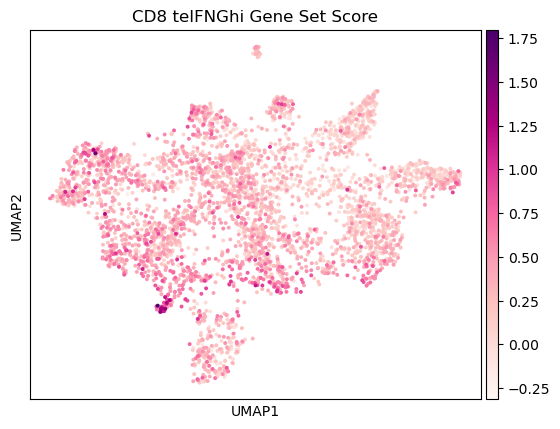

In [34]:
valid_CD8_teIFNGhi_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD8_teIFNGhi, 'CD8_teIFNGhi_score')

# Visualize the results if valid genes were found
if valid_CD8_teIFNGhi_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD8_teIFNGhi_score', cmap='RdPu', wspace=0.1, ncols=5, title='CD8 teIFNGhi Gene Set Score')

In [35]:
# CD 8 te+teIFNGhi
gene_set_CD8_te_and_teIFNGhi = ["Papio_anubis_AOAH", "Papio_anubis_PPP2R5C", "Papio_anubis_FYN", "Papio_anubis_CNOT6L", "Papio_anubis_PDE3B", "Papio_anubis_CEMIP2", "Papio_anubis_CAMK4", "Papio_anubis_AC016831.7", "Papio_anubis_PTPRC", "Papio_anubis_SYTL3", "Papio_anubis_ATXN1", "Papio_anubis_SMCHD1", "Papio_anubis_ATP8A1", "Papio_anubis_PITPNC1", "Papio_anubis_CBLB", "Papio_anubis_LYST", "Papio_anubis_P2RY8", "Papio_anubis_AKNA", "Papio_anubis_FOXP1", "Papio_anubis_PPP1R16B", "Papio_anubis_PARP8", "Papio_anubis_CRYBG1", "Papio_anubis_PRKCH", "Papio_anubis_IQGAP2", "Papio_anubis_DUSP2", "Papio_anubis_ETS1", "Papio_anubis_RUNX3", "Papio_anubis_FAM129A", "Papio_anubis_DTHD1", "Papio_anubis_CDC42SE2", "Papio_anubis_EML4", "Papio_anubis_BCL11B", "Papio_anubis_MVB12B", "Papio_anubis_KLF12", "Papio_anubis_SAMD3", "Papio_anubis_ITGA4", "Papio_anubis_ATXN7L1", "Papio_anubis_PIK3R1", "Papio_anubis_ARID5B", "Papio_anubis_EPB41", "Papio_anubis_TC2N", "Papio_anubis_SARAF", "Papio_anubis_FOXO1", "Papio_anubis_PHACTR2", "Papio_anubis_LITAF", "Papio_anubis_SYNE1", "Papio_anubis_WIPF1", "Papio_anubis_RASA3", "Papio_anubis_WNK1", "Papio_anubis_BICDL1", "Papio_anubis_ZEB2", "Papio_anubis_PIP4K2A", "Papio_anubis_RNF19A", "Papio_anubis_SLC38A1", "Papio_anubis_A2M", "Papio_anubis_RABGAP1L", "Papio_anubis_GALNT11", "Papio_anubis_STAT4", "Papio_anubis_MAML2", "Papio_anubis_TPRG1", "Papio_anubis_PZP", "Papio_anubis_NLRC5", "Papio_anubis_NIN", "Papio_anubis_TRERF1", "Papio_anubis_TNRC6B", "Papio_anubis_ITK", "Papio_anubis_PCAT1", "Papio_anubis_TNIP3", "Papio_anubis_JAKMIP1", "Papio_anubis_ZFP36L2", "Papio_anubis_STK38", "Papio_anubis_PYHIN1", "Papio_anubis_AL357060.1", "Papio_anubis_RAPGEF1", "Papio_anubis_CD84", "Papio_anubis_CREM", "Papio_anubis_THEMIS", "Papio_anubis_SIK3", "Papio_anubis_TGFBR3", "Papio_anubis_CMIP", "Papio_anubis_EMB", "Papio_anubis_ZNF831", "Papio_anubis_CCSER2", "Papio_anubis_TMEM181", "Papio_anubis_DDX5", "Papio_anubis_ARAP2", "Papio_anubis_PRKCQ", "Papio_anubis_TRPS1", "Papio_anubis_MPP7", "Papio_anubis_SGCD", "Papio_anubis_PSMA1", "Papio_anubis_MCOLN2", "Papio_anubis_MCUB", "Papio_anubis_NLRP1", "Papio_anubis_MRPL1", "Papio_anubis_PRKCB", "Papio_anubis_SAMSN1", "Papio_anubis_RNF125", "Papio_anubis_GTDC1", "Papio_anubis_STK4", "Papio_anubis_CCL4", "Papio_anubis_CCL3", "Papio_anubis_RNF19A", "Papio_anubis_CBLB", "Papio_anubis_RHOH", "Papio_anubis_GBP2", "Papio_anubis_GNG2", "Papio_anubis_NFKBID", "Papio_anubis_RAB8B", "Papio_anubis_DUSP2", "Papio_anubis_REL", "Papio_anubis_IFNG", "Papio_anubis_NR4A3", "Papio_anubis_PTPRC", "Papio_anubis_SLA", "Papio_anubis_SYTL3", "Papio_anubis_CRTAM", "Papio_anubis_YES1", "Papio_anubis_RILPL2", "Papio_anubis_NR4A2", "Papio_anubis_FYN", "Papio_anubis_CD69", "Papio_anubis_MIR155HG", "Papio_anubis_NFKBIA", "Papio_anubis_HLA-B", "Papio_anubis_THEMIS", "Papio_anubis_SP140", "Papio_anubis_TNF", "Papio_anubis_PRKCH", "Papio_anubis_HIF1A", "Papio_anubis_LYST", "Papio_anubis_AC022075.1", "Papio_anubis_ARID5B", "Papio_anubis_CCL5", "Papio_anubis_MAP3K8", "Papio_anubis_JARID2", "Papio_anubis_TNFAIP3", "Papio_anubis_DTHD1", "Papio_anubis_FNBP1", "Papio_anubis_B2M", "Papio_anubis_HNRNPC", "Papio_anubis_RAB27A", "Papio_anubis_ZEB2", "Papio_anubis_NR4A1", "Papio_anubis_HLA-C", "Papio_anubis_XCL2", "Papio_anubis_STAT4", "Papio_anubis_IPCEF1", "Papio_anubis_RASGEF1B", "Papio_anubis_PTPN22", "Papio_anubis_KLRD1", "Papio_anubis_IKZF3", "Papio_anubis_IGF2R", "Papio_anubis_HLA-E", "Papio_anubis_HIVEP2", "Papio_anubis_CAPZA1", "Papio_anubis_RAB11A", "Papio_anubis_KMT2E", "Papio_anubis_TAGAP", "Papio_anubis_TG", "Papio_anubis_ADGRE5", "Papio_anubis_AC243829.2", "Papio_anubis_NFKB1", "Papio_anubis_RAP1A", "Papio_anubis_OSBPL3", "Papio_anubis_GABPB1", "Papio_anubis_IRF8", "Papio_anubis_TANK", "Papio_anubis_GADD45B", "Papio_anubis_GFOD1", "Papio_anubis_TOX", "Papio_anubis_NKG7", "Papio_anubis_CEMIP2", "Papio_anubis_SERPINB9", "Papio_anubis_BAZ1A", "Papio_anubis_MCOLN2", "Papio_anubis_OPRM1", "Papio_anubis_GZMB", "Papio_anubis_PTPN7", "Papio_anubis_STK17B", "Papio_anubis_ID2", "Papio_anubis_FASLG", "Papio_anubis_SDCBP", "Papio_anubis_ITGA4", "Papio_anubis_CD8A", "Papio_anubis_HLA-A", "Papio_anubis_PYHIN1", "Papio_anubis_ARPC2", "Papio_anubis_TNFRSF1B", "Papio_anubis_NFATC2", "Papio_anubis_TRAF1", "Papio_anubis_PTGER4", "Papio_anubis_TRGC2", "Papio_anubis_ITPKB", "Papio_anubis_SRGN", "Papio_anubis_NAMPT", "Papio_anubis_IL21R", "Papio_anubis_FBXO11", "Papio_anubis_KLF6", "Papio_anubis_FOSL2"]

Gene set score 'CD8_te_and_teIFNGhi_score' calculated using 56 genes.
Valid genes: Papio_anubis_AOAH, Papio_anubis_PDE3B, Papio_anubis_CEMIP2, Papio_anubis_CAMK4, Papio_anubis_SYTL3, Papio_anubis_FOXP1, Papio_anubis_DTHD1, Papio_anubis_BCL11B, Papio_anubis_SAMD3, Papio_anubis_ATXN7L1, Papio_anubis_ARID5B, Papio_anubis_PHACTR2, Papio_anubis_LITAF, Papio_anubis_BICDL1, Papio_anubis_ZEB2, Papio_anubis_RNF19A, Papio_anubis_STAT4, Papio_anubis_TRERF1, Papio_anubis_TNIP3, Papio_anubis_ZFP36L2, Papio_anubis_CREM, Papio_anubis_THEMIS, Papio_anubis_TGFBR3, Papio_anubis_CMIP, Papio_anubis_ZNF831, Papio_anubis_TRPS1, Papio_anubis_MPP7, Papio_anubis_PSMA1, Papio_anubis_RNF19A, Papio_anubis_NFKBID, Papio_anubis_REL, Papio_anubis_IFNG, Papio_anubis_NR4A3, Papio_anubis_SYTL3, Papio_anubis_CRTAM, Papio_anubis_RILPL2, Papio_anubis_NR4A2, Papio_anubis_NFKBIA, Papio_anubis_THEMIS, Papio_anubis_ARID5B, Papio_anubis_MAP3K8, Papio_anubis_JARID2, Papio_anubis_DTHD1, Papio_anubis_ZEB2, Papio_anubis_NR4A1, Pap

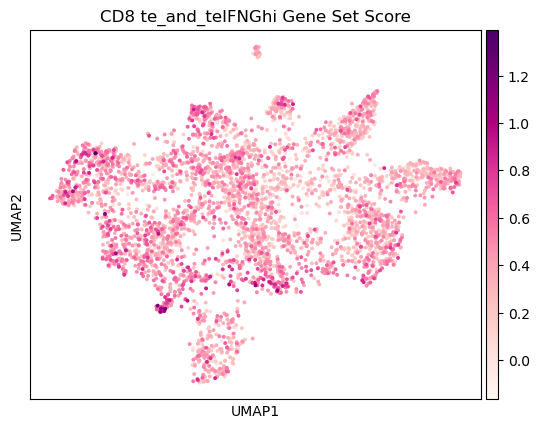

In [36]:
valid_CD8_te_and_teIFNGhi_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD8_te_and_teIFNGhi, 'CD8_te_and_teIFNGhi_score')

# Visualize the results if valid genes were found
if valid_CD8_te_and_teIFNGhi_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD8_te_and_teIFNGhi_score', cmap='RdPu', wspace=0.1, ncols=5, title='CD8 te_and_teIFNGhi Gene Set Score')

# CD8 trans

In [37]:
gene_set_CD8_trans = ["Papio_anubis_THEMIS", "Papio_anubis_TC2N", "Papio_anubis_DTHD1", "Papio_anubis_AOAH", "Papio_anubis_LINC01934", "Papio_anubis_TOX", "Papio_anubis_ATXN1", "Papio_anubis_FYB1", "Papio_anubis_PPP2R2B", "Papio_anubis_INPP4B", "Papio_anubis_SKAP1", "Papio_anubis_ARHGAP26", "Papio_anubis_AC022075.1", "Papio_anubis_KIAA1551", "Papio_anubis_CD2", "Papio_anubis_CCL5", "Papio_anubis_SFMBT2", "Papio_anubis_JAKMIP1", "Papio_anubis_SLFN12L", "Papio_anubis_CAMK4", "Papio_anubis_PARP8", "Papio_anubis_BCL11B", "Papio_anubis_RUNX1", "Papio_anubis_MSC-AS1", "Papio_anubis_PDE7A", "Papio_anubis_PIP4K2A", "Papio_anubis_SAMD3", "Papio_anubis_A2M", "Papio_anubis_CD44", "Papio_anubis_ARAP2", "Papio_anubis_CDC42SE2", "Papio_anubis_GZMK", "Papio_anubis_WNK1", "Papio_anubis_ATP8A1", "Papio_anubis_STK17A", "Papio_anubis_RBL2", "Papio_anubis_GRAP2", "Papio_anubis_PITPNC1", "Papio_anubis_MVB12B", "Papio_anubis_WIPF1", "Papio_anubis_NIN", "Papio_anubis_EPS15", "Papio_anubis_KLRG1", "Papio_anubis_SLF1", "Papio_anubis_CD8B", "Papio_anubis_GZMA", "Papio_anubis_PTPRC", "Papio_anubis_CD69", "Papio_anubis_TNIP3", "Papio_anubis_PZP", "Papio_anubis_TPRG1", "Papio_anubis_CBLB", "Papio_anubis_EML4", "Papio_anubis_APBB1IP", "Papio_anubis_C15orf53", "Papio_anubis_TTN", "Papio_anubis_PCNX2", "Papio_anubis_CD8A", "Papio_anubis_MDFIC", "Papio_anubis_AC015849.1", "Papio_anubis_ARHGAP35", "Papio_anubis_PDCD4", "Papio_anubis_AF165147.1", "Papio_anubis_NLRC5", "Papio_anubis_LINC00649", "Papio_anubis_ITGAL", "Papio_anubis_SOS1", "Papio_anubis_EMB", "Papio_anubis_BICDL1", "Papio_anubis_LCP2", "Papio_anubis_MBNL1", "Papio_anubis_GPRIN3", "Papio_anubis_JAKMIP2", "Papio_anubis_CYTOR", "Papio_anubis_ZBTB38", "Papio_anubis_LYST", "Papio_anubis_ST8SIA1", "Papio_anubis_HIP1", "Papio_anubis_NCK2", "Papio_anubis_SLAMF6", "Papio_anubis_AC104078.2", "Papio_anubis_PYHIN1", "Papio_anubis_LRBA", "Papio_anubis_CATSPERB", "Papio_anubis_SLC9A9", "Papio_anubis_TSPAN5", "Papio_anubis_MYCBP2", "Papio_anubis_MALAT1", "Papio_anubis_TTC39B", "Papio_anubis_CLEC2D", "Papio_anubis_CD3G", "Papio_anubis_GTDC1", "Papio_anubis_FYN", "Papio_anubis_ARHGAP25", "Papio_anubis_MCOLN2", "Papio_anubis_MIR4435-2HG", "Papio_anubis_GPR174", "Papio_anubis_IKZF3", "Papio_anubis_ARHGAP18", "Papio_anubis_PTGDR"]

Gene set score 'CD8_trans_score' calculated using 22 genes.
Valid genes: Papio_anubis_THEMIS, Papio_anubis_DTHD1, Papio_anubis_AOAH, Papio_anubis_PPP2R2B, Papio_anubis_SFMBT2, Papio_anubis_CAMK4, Papio_anubis_BCL11B, Papio_anubis_RUNX1, Papio_anubis_SAMD3, Papio_anubis_TNIP3, Papio_anubis_TTN, Papio_anubis_PCNX2, Papio_anubis_MDFIC, Papio_anubis_SOS1, Papio_anubis_BICDL1, Papio_anubis_GPRIN3, Papio_anubis_JAKMIP2, Papio_anubis_ST8SIA1, Papio_anubis_HIP1, Papio_anubis_SLAMF6, Papio_anubis_TSPAN5, Papio_anubis_ARHGAP18

Gene Scores:
                 Gene  Mean Expression  Variance            CV
    Papio_anubis_HIP1     3.537743e-08  0.999735  2.826287e+07
   Papio_anubis_MDFIC     3.234507e-08  0.999735  3.091251e+07
    Papio_anubis_AOAH     2.830194e-08  0.999735  3.532858e+07
  Papio_anubis_BCL11B     2.830194e-08  0.999735  3.532859e+07
   Papio_anubis_RUNX1     2.830194e-08  0.999735  3.532858e+07
 Papio_anubis_PPP2R2B     2.223724e-08  0.999735  4.496365e+07
  Papio_anubis_SLAMF6 

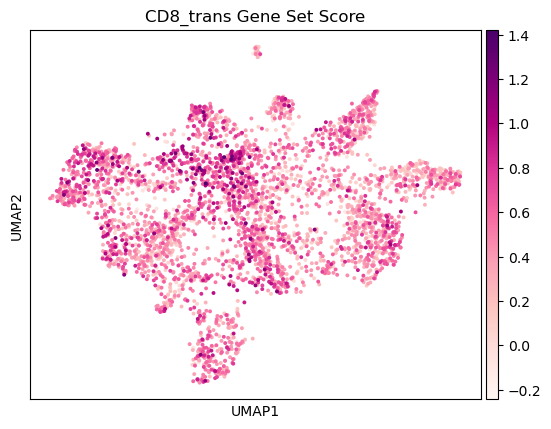

In [38]:
valid_CD8_trans_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD8_trans, 'CD8_trans_score')

# Visualize the results if valid genes were found
if valid_CD8_trans_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD8_trans_score', cmap='RdPu', wspace=0.1, ncols=5, title='CD8_trans Gene Set Score')

Gene set score 'CD8_trans_score' calculated using 22 genes.
Valid genes: Papio_anubis_THEMIS, Papio_anubis_DTHD1, Papio_anubis_AOAH, Papio_anubis_PPP2R2B, Papio_anubis_SFMBT2, Papio_anubis_CAMK4, Papio_anubis_BCL11B, Papio_anubis_RUNX1, Papio_anubis_SAMD3, Papio_anubis_TNIP3, Papio_anubis_TTN, Papio_anubis_PCNX2, Papio_anubis_MDFIC, Papio_anubis_SOS1, Papio_anubis_BICDL1, Papio_anubis_GPRIN3, Papio_anubis_JAKMIP2, Papio_anubis_ST8SIA1, Papio_anubis_HIP1, Papio_anubis_SLAMF6, Papio_anubis_TSPAN5, Papio_anubis_ARHGAP18

Gene Scores:
                 Gene  Mean Expression  Variance            CV
    Papio_anubis_HIP1     3.537743e-08  0.999735  2.826287e+07
   Papio_anubis_MDFIC     3.234507e-08  0.999735  3.091251e+07
    Papio_anubis_AOAH     2.830194e-08  0.999735  3.532858e+07
  Papio_anubis_BCL11B     2.830194e-08  0.999735  3.532859e+07
   Papio_anubis_RUNX1     2.830194e-08  0.999735  3.532858e+07
 Papio_anubis_PPP2R2B     2.223724e-08  0.999735  4.496365e+07
  Papio_anubis_SLAMF6 

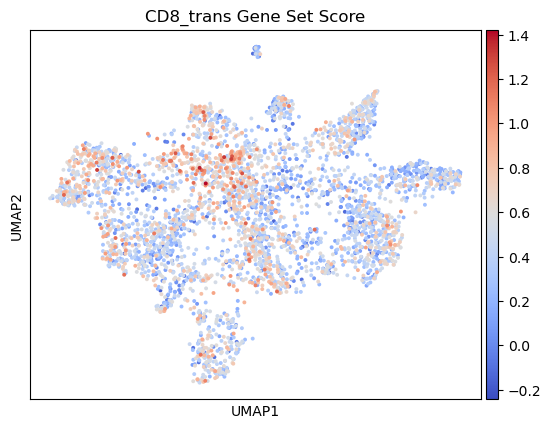

In [39]:
valid_CD8_trans_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_CD8_trans, 'CD8_trans_score')

# Visualize the results if valid genes were found
if valid_CD8_trans_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='CD8_trans_score', cmap='coolwarm', wspace=0.1, ncols=5, title='CD8_trans Gene Set Score')

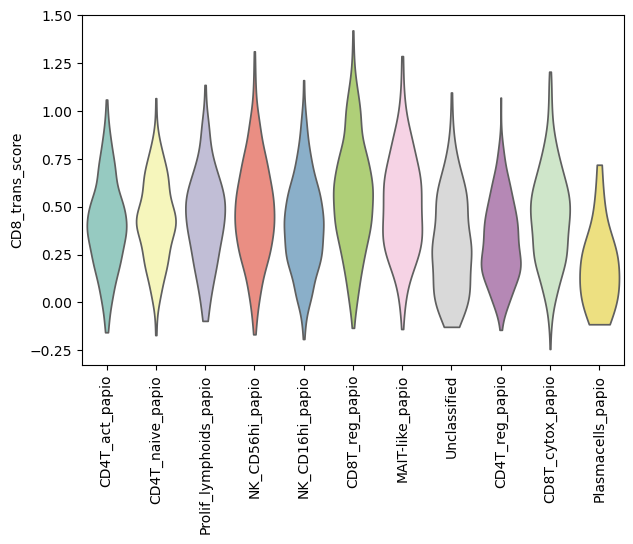

In [40]:
sc.pl.violin(
    LYMPHOIDS_harmony,
    keys="CD8_trans_score",
    groupby="leiden_named_08",
    rotation=90,
    stripplot=False
)

# ILC

In [41]:

gene_set_ILC = ["Papio_anubis_TXK", "Papio_anubis_AFF3", "Papio_anubis_RUNX2", "Papio_anubis_LINC00299", "Papio_anubis_MAML3", "Papio_anubis_SSBP2", "Papio_anubis_ATP8B4", "Papio_anubis_NCALD", "Papio_anubis_GNLY", "Papio_anubis_IL18R1", "Papio_anubis_BACH2", "Papio_anubis_AUTS2", "Papio_anubis_PPP1R9A", "Papio_anubis_IL7R", "Papio_anubis_GNAQ", "Papio_anubis_TEC", "Papio_anubis_MAML2", "Papio_anubis_PLXDC2", "Papio_anubis_HIP1", "Papio_anubis_ETV6", "Papio_anubis_XYLT1", "Papio_anubis_KLRC1", "Papio_anubis_AREG", "Papio_anubis_ATP10A", "Papio_anubis_MGAT5", "Papio_anubis_TLE1", "Papio_anubis_NCAM1", "Papio_anubis_ZBTB16", "Papio_anubis_IRAK3", "Papio_anubis_UBASH3B", "Papio_anubis_DACH1", "Papio_anubis_VAV3", "Papio_anubis_SYK", "Papio_anubis_GAS7", "Papio_anubis_SVIL", "Papio_anubis_LRMDA", "Papio_anubis_DOCK5", "Papio_anubis_SMYD3", "Papio_anubis_IGF1R", "Papio_anubis_AKT3", "Papio_anubis_LDLRAD3", "Papio_anubis_TNFRSF18", "Papio_anubis_MCTP2", "Papio_anubis_IMMP2L", "Papio_anubis_PLCL2", "Papio_anubis_PLCG2", "Papio_anubis_PCDH9", "Papio_anubis_TIAM1", "Papio_anubis_ABCC1", "Papio_anubis_BAZ2B", "Papio_anubis_DDIT4", "Papio_anubis_ZFHX3", "Papio_anubis_RNF130", "Papio_anubis_UST", "Papio_anubis_CHKA", "Papio_anubis_CERS6", "Papio_anubis_FKBP5", "Papio_anubis_KCNQ5", "Papio_anubis_KANSL1L", "Papio_anubis_LINC02256", "Papio_anubis_AC008014.1", "Papio_anubis_PDZD2", "Papio_anubis_EVA1C", "Papio_anubis_ITGAX", "Papio_anubis_PRKG1", "Papio_anubis_TARSL2", "Papio_anubis_CLASP1", "Papio_anubis_EXT1", "Papio_anubis_MED13L", "Papio_anubis_EPHA4", "Papio_anubis_ZBTB20", "Papio_anubis_ZNF609", "Papio_anubis_SRGAP3", "Papio_anubis_FRY", "Papio_anubis_C22orf34", "Papio_anubis_SELL", "Papio_anubis_PLXNA4", "Papio_anubis_COL24A1", "Papio_anubis_TRIO", "Papio_anubis_RAPGEF2", "Papio_anubis_FHIT", "Papio_anubis_ST3GAL1", "Papio_anubis_PATJ", "Papio_anubis_AGPAT4", "Papio_anubis_PDE8A", "Papio_anubis_TNFRSF11A", "Papio_anubis_SAMD12", "Papio_anubis_PLCB1", "Papio_anubis_RPS6KA2", "Papio_anubis_FOXJ3", "Papio_anubis_AL357793.1", "Papio_anubis_ID2", "Papio_anubis_ERGIC1", "Papio_anubis_PIK3R1", "Papio_anubis_RIPOR2", "Papio_anubis_AL034397.3", "Papio_anubis_KLRF1", "Papio_anubis_LYN", "Papio_anubis_CLNK", "Papio_anubis_ZFP36L2"]

Gene set score 'ILC_score' calculated using 57 genes.
Valid genes: Papio_anubis_AFF3, Papio_anubis_RUNX2, Papio_anubis_MAML3, Papio_anubis_SSBP2, Papio_anubis_NCALD, Papio_anubis_GNLY, Papio_anubis_BACH2, Papio_anubis_AUTS2, Papio_anubis_PPP1R9A, Papio_anubis_IL7R, Papio_anubis_GNAQ, Papio_anubis_TEC, Papio_anubis_PLXDC2, Papio_anubis_HIP1, Papio_anubis_KLRC1, Papio_anubis_TLE1, Papio_anubis_NCAM1, Papio_anubis_ZBTB16, Papio_anubis_IRAK3, Papio_anubis_UBASH3B, Papio_anubis_DACH1, Papio_anubis_VAV3, Papio_anubis_SYK, Papio_anubis_GAS7, Papio_anubis_SVIL, Papio_anubis_LRMDA, Papio_anubis_DOCK5, Papio_anubis_IGF1R, Papio_anubis_LDLRAD3, Papio_anubis_MCTP2, Papio_anubis_IMMP2L, Papio_anubis_PLCG2, Papio_anubis_BAZ2B, Papio_anubis_DDIT4, Papio_anubis_ZFHX3, Papio_anubis_RNF130, Papio_anubis_UST, Papio_anubis_CERS6, Papio_anubis_FKBP5, Papio_anubis_KCNQ5, Papio_anubis_PDZD2, Papio_anubis_ITGAX, Papio_anubis_EXT1, Papio_anubis_FRY, Papio_anubis_SELL, Papio_anubis_PLXNA4, Papio_anubis_TRIO, Pa

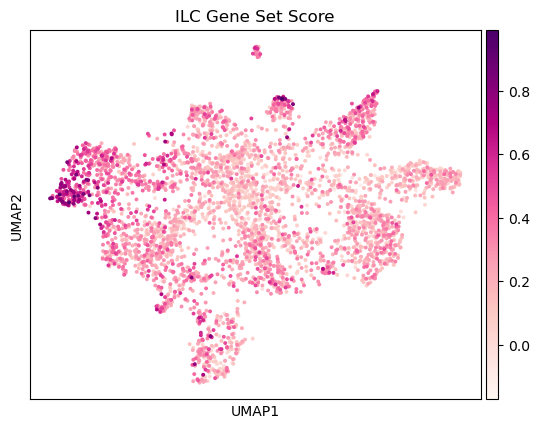

In [42]:
valid_ILC_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_ILC, 'ILC_score')

# Visualize the results if valid genes were found
if valid_ILC_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='ILC_score', cmap='RdPu', wspace=0.1, ncols=5, title='ILC Gene Set Score')

# MAIT like 

In [43]:
gene_set_MAIT = ["Papio_anubis_IL7R", "Papio_anubis_TTC39C", "Papio_anubis_RORA", "Papio_anubis_PLCB1", "Papio_anubis_RUNX2", "Papio_anubis_MYBL1", "Papio_anubis_TC2N", "Papio_anubis_PZP", "Papio_anubis_SLC4A10", "Papio_anubis_ERN1", "Papio_anubis_PHACTR2", "Papio_anubis_PARP8", "Papio_anubis_RBMS1", "Papio_anubis_DPP4", "Papio_anubis_A2M", "Papio_anubis_CAMK4", "Papio_anubis_IL18RAP", "Papio_anubis_ODF2L", "Papio_anubis_KLRB1", "Papio_anubis_KLRG1", "Papio_anubis_ATF7IP2", "Papio_anubis_ANK3", "Papio_anubis_RASGRF2", "Papio_anubis_CDC14A", "Papio_anubis_NR3C2", "Papio_anubis_COLQ", "Papio_anubis_CASK", "Papio_anubis_RORA-AS1", "Papio_anubis_IL12RB2", "Papio_anubis_IFNG-AS1", "Papio_anubis_TXNIP", "Papio_anubis_JAML", "Papio_anubis_MGAT4A", "Papio_anubis_SESN1", "Papio_anubis_TLE1", "Papio_anubis_BTBD11", "Papio_anubis_ABCB1", "Papio_anubis_CD96", "Papio_anubis_SYTL2", "Papio_anubis_ZFP36L2", "Papio_anubis_LINC01871", "Papio_anubis_EVA1C", "Papio_anubis_SYNE2", "Papio_anubis_THEMIS", "Papio_anubis_PAG1", "Papio_anubis_MGAT5", "Papio_anubis_STAT4", "Papio_anubis_OXNAD1", "Papio_anubis_PDCD4", "Papio_anubis_EML4", "Papio_anubis_SPOCK2", "Papio_anubis_SIPA1L1", "Papio_anubis_PDE4D", "Papio_anubis_GRAP2", "Papio_anubis_IL18R1", "Papio_anubis_SIK3", "Papio_anubis_ADAM10", "Papio_anubis_ADAM12", "Papio_anubis_MALAT1", "Papio_anubis_AC006369.1", "Papio_anubis_ZBTB16", "Papio_anubis_PBX4", "Papio_anubis_AAK1", "Papio_anubis_TANC2", "Papio_anubis_LINC00623", "Papio_anubis_PATJ", "Papio_anubis_PCNX2", "Papio_anubis_SPIDR", "Papio_anubis_PDE7A", "Papio_anubis_PLD1", "Papio_anubis_NEK7", "Papio_anubis_BTG1", "Papio_anubis_PRKCA", "Papio_anubis_CD2", "Papio_anubis_CATSPERB", "Papio_anubis_PTPN13", "Papio_anubis_BCL2", "Papio_anubis_AKT3", "Papio_anubis_PITPNC1", "Papio_anubis_CCR6", "Papio_anubis_NEO1", "Papio_anubis_CD40LG", "Papio_anubis_LINC01644", "Papio_anubis_PIP4K2A", "Papio_anubis_TNRC6B", "Papio_anubis_CELF2", "Papio_anubis_MPP7", "Papio_anubis_LUZP1", "Papio_anubis_IL23R", "Papio_anubis_ME1", "Papio_anubis_TNFAIP8", "Papio_anubis_ARHGAP15", "Papio_anubis_LINC00513", "Papio_anubis_GALNT10", "Papio_anubis_CYTH3", "Papio_anubis_SCART1", "Papio_anubis_AUTS2", "Papio_anubis_TMEM117", "Papio_anubis_KIF5C", "Papio_anubis_SNX9"]

Gene set score 'MAIT_score' calculated using 40 genes.
Valid genes: Papio_anubis_IL7R, Papio_anubis_PLCB1, Papio_anubis_RUNX2, Papio_anubis_SLC4A10, Papio_anubis_PHACTR2, Papio_anubis_DPP4, Papio_anubis_CAMK4, Papio_anubis_KLRB1, Papio_anubis_ANK3, Papio_anubis_RASGRF2, Papio_anubis_CDC14A, Papio_anubis_NR3C2, Papio_anubis_COLQ, Papio_anubis_CASK, Papio_anubis_IL12RB2, Papio_anubis_JAML, Papio_anubis_SESN1, Papio_anubis_TLE1, Papio_anubis_CD96, Papio_anubis_SYTL2, Papio_anubis_ZFP36L2, Papio_anubis_SYNE2, Papio_anubis_THEMIS, Papio_anubis_PAG1, Papio_anubis_STAT4, Papio_anubis_SIPA1L1, Papio_anubis_PDE4D, Papio_anubis_ADAM12, Papio_anubis_ZBTB16, Papio_anubis_TANC2, Papio_anubis_PATJ, Papio_anubis_PCNX2, Papio_anubis_BTG1, Papio_anubis_PTPN13, Papio_anubis_MPP7, Papio_anubis_LUZP1, Papio_anubis_IL23R, Papio_anubis_TNFAIP8, Papio_anubis_AUTS2, Papio_anubis_TMEM117

Gene Scores:
                Gene  Mean Expression  Variance            CV
Papio_anubis_SLC4A10     4.043134e-08  0.999735 

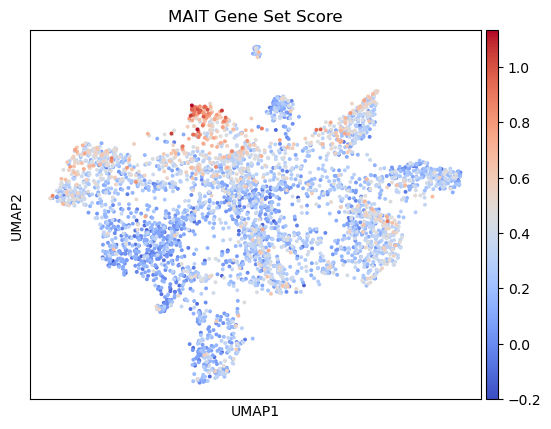

In [44]:
valid_MAIT_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_MAIT, 'MAIT_score')

# Visualize the results if valid genes were found
if valid_MAIT_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='MAIT_score', cmap='coolwarm', wspace=0.1, ncols=5, title='MAIT Gene Set Score')

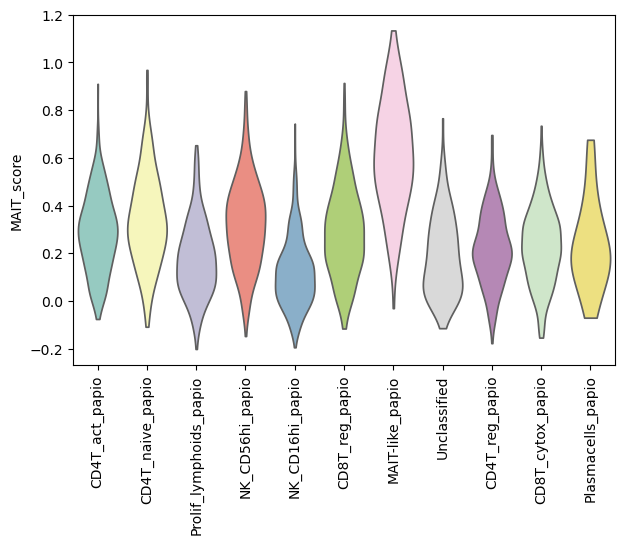

In [45]:
sc.pl.violin(
    LYMPHOIDS_harmony,
    keys="MAIT_score",
    groupby="leiden_named_08",
    rotation=90,
    stripplot=False
)

# Plasmacells

In [46]:

gene_set_Plasmacell = ["Papio_anubis_FNDC3B", "Papio_anubis_CREB3L2", "Papio_anubis_CARMIL1", "Papio_anubis_GAB1", "Papio_anubis_FNDC3A", "Papio_anubis_DENND5B", "Papio_anubis_FBXW7", "Papio_anubis_GLCCI1", "Papio_anubis_LRRK1", "Papio_anubis_ELL2", "Papio_anubis_XBP1", "Papio_anubis_GNG7", "Papio_anubis_POU2AF1", "Papio_anubis_CDK14", "Papio_anubis_AC008014.1", "Papio_anubis_TENT5C", "Papio_anubis_IGKC", "Papio_anubis_RALGPS2", "Papio_anubis_SPATS2", "Papio_anubis_HERPUD1", "Papio_anubis_MYO1D", "Papio_anubis_MEF2C", "Papio_anubis_NDUFAF6", "Papio_anubis_MEI1", "Papio_anubis_PDK1", "Papio_anubis_FCRL5", "Papio_anubis_ST6GAL1", "Papio_anubis_MZB1", "Papio_anubis_IFNG-AS1", "Papio_anubis_SEL1L3", "Papio_anubis_FCHSD2", "Papio_anubis_TXNDC11", "Papio_anubis_SEC14L1", "Papio_anubis_INSR", "Papio_anubis_CPEB4", "Papio_anubis_SEC24D", "Papio_anubis_RAB30", "Papio_anubis_TPD52", "Papio_anubis_ANKRD28", "Papio_anubis_CHST15", "Papio_anubis_VOPP1", "Papio_anubis_NEAT1", "Papio_anubis_TP53INP1", "Papio_anubis_NCOA3", "Papio_anubis_EIF2AK3", "Papio_anubis_SEC24A", "Papio_anubis_MSI2", "Papio_anubis_TRIO", "Papio_anubis_PLCG2", "Papio_anubis_GMDS-DT", "Papio_anubis_RRBP1", "Papio_anubis_TRAF3", "Papio_anubis_ESR1", "Papio_anubis_HSH2D", "Papio_anubis_MAN1A1", "Papio_anubis_MED13L", "Papio_anubis_IGLL5", "Papio_anubis_UBE2E2", "Papio_anubis_FHIT", "Papio_anubis_SPCS2", "Papio_anubis_MERTK", "Papio_anubis_SLC44A1", "Papio_anubis_SND1", "Papio_anubis_KLHL6", "Papio_anubis_NUGGC", "Papio_anubis_IGHG1", "Papio_anubis_EVI5", "Papio_anubis_GMDS", "Papio_anubis_WNT5B", "Papio_anubis_RBM47", "Papio_anubis_ARFGEF2", "Papio_anubis_IGHGP", "Papio_anubis_PIP5K1B", "Papio_anubis_FOXO3", "Papio_anubis_AC092546.1", "Papio_anubis_TRAM2", "Papio_anubis_USP48", "Papio_anubis_MBNL2", "Papio_anubis_KANK1", "Papio_anubis_BLNK", "Papio_anubis_ETV6", "Papio_anubis_UBE2J1", "Papio_anubis_DNAJC1", "Papio_anubis_TNS3", "Papio_anubis_EIF2AK4", "Papio_anubis_COBLL1", "Papio_anubis_HM13", "Papio_anubis_FUT8", "Papio_anubis_SEC31A", "Papio_anubis_LARP1B", "Papio_anubis_PIM2", "Papio_anubis_CADPS2", "Papio_anubis_IGHG3", "Papio_anubis_LINC02362", "Papio_anubis_RIC1", "Papio_anubis_BICD1", "Papio_anubis_AC078883.1", "Papio_anubis_CEP128", "Papio_anubis_IGHA1", "Papio_anubis_LARGE1"]

Gene set score 'Plasmacell_score' calculated using 26 genes.
Valid genes: Papio_anubis_CARMIL1, Papio_anubis_GAB1, Papio_anubis_DENND5B, Papio_anubis_GLCCI1, Papio_anubis_CDK14, Papio_anubis_RALGPS2, Papio_anubis_MYO1D, Papio_anubis_MEF2C, Papio_anubis_FCRL5, Papio_anubis_INSR, Papio_anubis_CPEB4, Papio_anubis_TPD52, Papio_anubis_CHST15, Papio_anubis_TRIO, Papio_anubis_PLCG2, Papio_anubis_ESR1, Papio_anubis_UBE2E2, Papio_anubis_FHIT, Papio_anubis_EVI5, Papio_anubis_PIP5K1B, Papio_anubis_TRAM2, Papio_anubis_BLNK, Papio_anubis_TNS3, Papio_anubis_CADPS2, Papio_anubis_CEP128, Papio_anubis_LARGE1

Gene Scores:
                Gene  Mean Expression  Variance            CV
  Papio_anubis_TRAM2     4.245291e-08  0.999735  2.355239e+07
Papio_anubis_CARMIL1     3.638821e-08  0.999735  2.747779e+07
  Papio_anubis_MYO1D     2.425881e-08  0.999735  4.121668e+07
   Papio_anubis_TNS3     2.274263e-08  0.999735  4.396446e+07
  Papio_anubis_FCRL5     2.223724e-08  0.999735  4.496365e+07
   Papio_anubis

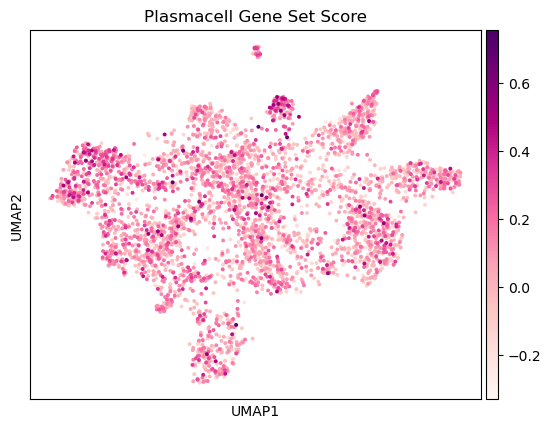

In [47]:
valid_Plasmacell_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_Plasmacell, 'Plasmacell_score')

# Visualize the results if valid genes were found
if valid_Plasmacell_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='Plasmacell_score', cmap='RdPu', wspace=0.1, ncols=5, title='Plasmacell Gene Set Score')

# NK CD 56 pos

In [48]:
gene_set_NK_CD56pos = ["Papio_anubis_TXK", "Papio_anubis_MCTP2", "Papio_anubis_LDB2", "Papio_anubis_KLRC1", "Papio_anubis_AOAH", "Papio_anubis_ADAMTS17", "Papio_anubis_AUTS2", "Papio_anubis_ATP8B4", "Papio_anubis_ZBTB16", "Papio_anubis_NCAM1", "Papio_anubis_KLRD1", "Papio_anubis_HIP1", "Papio_anubis_PLCB1", "Papio_anubis_CLASP1", "Papio_anubis_SYK", "Papio_anubis_PLCG2", "Papio_anubis_KCNQ5", "Papio_anubis_RUNX2", "Papio_anubis_NCR1", "Papio_anubis_CD96", "Papio_anubis_L3MBTL4", "Papio_anubis_SFMBT2", "Papio_anubis_PDGFD", "Papio_anubis_TOX", "Papio_anubis_CLNK", "Papio_anubis_AC022075.1", "Papio_anubis_ABCB1", "Papio_anubis_RASA2", "Papio_anubis_CD247", "Papio_anubis_COLQ", "Papio_anubis_RIN3", "Papio_anubis_PIP4K2A", "Papio_anubis_GFOD1", "Papio_anubis_MAPK1", "Papio_anubis_TANC2", "Papio_anubis_PITPNC1", "Papio_anubis_GPATCH8", "Papio_anubis_TLE1", "Papio_anubis_APBA2", "Papio_anubis_STK17A", "Papio_anubis_HIPK2", "Papio_anubis_MAML2", "Papio_anubis_KLRF1", "Papio_anubis_PTGDR", "Papio_anubis_KANSL1L", "Papio_anubis_RASA1", "Papio_anubis_KLRC4-KLRK1", "Papio_anubis_PARP8", "Papio_anubis_FYN", "Papio_anubis_HELZ", "Papio_anubis_RAP1GDS1", "Papio_anubis_SYTL3", "Papio_anubis_TGFBR2", "Papio_anubis_LINC00623", "Papio_anubis_IGF1R", "Papio_anubis_MBNL1", "Papio_anubis_GNAQ", "Papio_anubis_ZNF609", "Papio_anubis_TTC39B", "Papio_anubis_HDAC9", "Papio_anubis_FAM49B", "Papio_anubis_PDE7A", "Papio_anubis_GLCCI1", "Papio_anubis_KLRB1", "Papio_anubis_TOX2", "Papio_anubis_UBASH3B", "Papio_anubis_CASK", "Papio_anubis_GAS7", "Papio_anubis_UST", "Papio_anubis_IL12RB2", "Papio_anubis_CTBP2", "Papio_anubis_MAML3", "Papio_anubis_SKAP2", "Papio_anubis_SIK3", "Papio_anubis_NCALD", "Papio_anubis_NOL4L", "Papio_anubis_RNF125", "Papio_anubis_IL2RB", "Papio_anubis_AF165147.1", "Papio_anubis_SCML4", "Papio_anubis_LYN", "Papio_anubis_AC245297.3", "Papio_anubis_SSH2", "Papio_anubis_SRGN", "Papio_anubis_MMP25-AS1", "Papio_anubis_ARHGAP26", "Papio_anubis_CCL3", "Papio_anubis_TNR", "Papio_anubis_SESN1", "Papio_anubis_YPEL1", "Papio_anubis_VAV3", "Papio_anubis_PYHIN1", "Papio_anubis_DHRS3", "Papio_anubis_SLC4A4", "Papio_anubis_NCOA1", "Papio_anubis_CHPT1", "Papio_anubis_AL031599.1", "Papio_anubis_AGTPBP1", "Papio_anubis_AC243829.4", "Papio_anubis_PDCD4"]

Gene set score 'NK_CD56pos_score' calculated using 46 genes.
Valid genes: Papio_anubis_MCTP2, Papio_anubis_LDB2, Papio_anubis_KLRC1, Papio_anubis_AOAH, Papio_anubis_ADAMTS17, Papio_anubis_AUTS2, Papio_anubis_ZBTB16, Papio_anubis_NCAM1, Papio_anubis_KLRD1, Papio_anubis_HIP1, Papio_anubis_PLCB1, Papio_anubis_SYK, Papio_anubis_PLCG2, Papio_anubis_KCNQ5, Papio_anubis_RUNX2, Papio_anubis_NCR1, Papio_anubis_CD96, Papio_anubis_L3MBTL4, Papio_anubis_SFMBT2, Papio_anubis_PDGFD, Papio_anubis_CLNK, Papio_anubis_COLQ, Papio_anubis_RIN3, Papio_anubis_GFOD1, Papio_anubis_TANC2, Papio_anubis_TLE1, Papio_anubis_APBA2, Papio_anubis_SYTL3, Papio_anubis_IGF1R, Papio_anubis_GNAQ, Papio_anubis_GLCCI1, Papio_anubis_KLRB1, Papio_anubis_UBASH3B, Papio_anubis_CASK, Papio_anubis_GAS7, Papio_anubis_UST, Papio_anubis_IL12RB2, Papio_anubis_CTBP2, Papio_anubis_MAML3, Papio_anubis_SKAP2, Papio_anubis_NCALD, Papio_anubis_SCML4, Papio_anubis_LYN, Papio_anubis_SESN1, Papio_anubis_VAV3, Papio_anubis_DHRS3

Gene Scores:


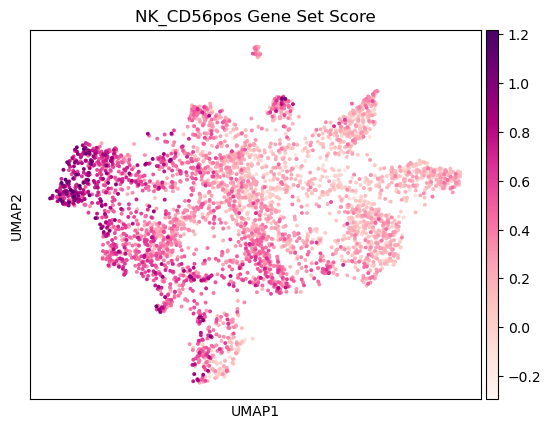

In [49]:
valid_NK_CD56pos_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_NK_CD56pos, 'NK_CD56pos_score')

# Visualize the results if valid genes were found
if valid_NK_CD56pos_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='NK_CD56pos_score', cmap='RdPu', wspace=0.1, ncols=5, title='NK_CD56pos Gene Set Score')

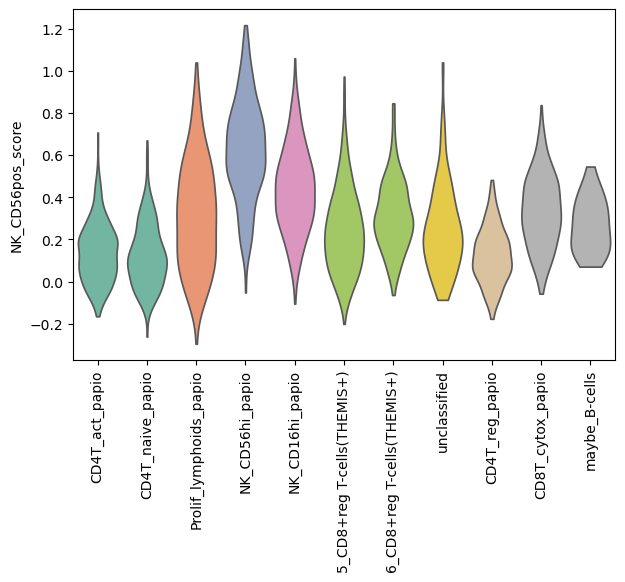

In [37]:
sc.pl.violin(
    LYMPHOIDS_harmony,
    keys="NK_CD56pos_score",
    groupby="leiden_named_08",
    rotation=90,
    stripplot=False
)

# NK CD16 pos

In [54]:
gene_set_NK_CD16pos = ['Papio_anubis_CD247', 'Papio_anubis_GSAP', 'Papio_anubis_SPON2', 'Papio_anubis_ZEB2', 'Papio_anubis_GNLY', 'Papio_anubis_TXK', 
'Papio_anubis_MCTP2', 'Papio_anubis_RAP1GAP2', 'Papio_anubis_KLRD1', 'Papio_anubis_BNC2', 'Papio_anubis_PTPN12', 'Papio_anubis_KLRF1', 
'Papio_anubis_FNDC3B', 'Papio_anubis_CARD11', 'Papio_anubis_CTBP2', 'Papio_anubis_VAV3', 'Papio_anubis_HIPK2', 'Papio_anubis_SYNE1', 
'Papio_anubis_OSBPL5', 'Papio_anubis_C1orf21', 'Papio_anubis_AOAH', 'Papio_anubis_MTSS1', 'Papio_anubis_TBXAS1', 'Papio_anubis_GFOD1', 
'Papio_anubis_UTRN', 'Papio_anubis_PPM1L', 'Papio_anubis_NCALD', 'Papio_anubis_MYO1F', 'Papio_anubis_TGFBR3', 'Papio_anubis_PLCB1', 
'Papio_anubis_EIF4G3', 'Papio_anubis_LINGO2', 'Papio_anubis_RAP1B', 'Papio_anubis_GNG2', 'Papio_anubis_JAZF1', 'Papio_anubis_GPATCH8', 
'Papio_anubis_LYN', 'Papio_anubis_ADGRG5', 'Papio_anubis_BIN2', 'Papio_anubis_PYHIN1', 'Papio_anubis_PDGFD', 'Papio_anubis_DIP2A', 
'Papio_anubis_NCAM1', 'Papio_anubis_APBA2', 'Papio_anubis_PRF1', 'Papio_anubis_SAMD3']

Gene set score 'NK_CD16pos_score' calculated using 24 genes.
Valid genes: Papio_anubis_GSAP, Papio_anubis_ZEB2, Papio_anubis_GNLY, Papio_anubis_MCTP2, Papio_anubis_RAP1GAP2, Papio_anubis_KLRD1, Papio_anubis_BNC2, Papio_anubis_PTPN12, Papio_anubis_CTBP2, Papio_anubis_VAV3, Papio_anubis_C1orf21, Papio_anubis_AOAH, Papio_anubis_MTSS1, Papio_anubis_TBXAS1, Papio_anubis_GFOD1, Papio_anubis_PPM1L, Papio_anubis_NCALD, Papio_anubis_TGFBR3, Papio_anubis_PLCB1, Papio_anubis_LYN, Papio_anubis_PDGFD, Papio_anubis_NCAM1, Papio_anubis_APBA2, Papio_anubis_SAMD3

Gene Scores:
                 Gene  Mean Expression  Variance            CV
   Papio_anubis_KLRD1     4.043134e-08  0.999735  2.473001e+07
    Papio_anubis_GSAP     2.931272e-08  0.999735  3.411036e+07
    Papio_anubis_AOAH     2.830194e-08  0.999735  3.532858e+07
  Papio_anubis_TGFBR3     2.830194e-08  0.999735  3.532858e+07
   Papio_anubis_NCALD     1.819410e-08  0.999735  5.495558e+07
Papio_anubis_RAP1GAP2     1.212940e-08  0.999735  8.243

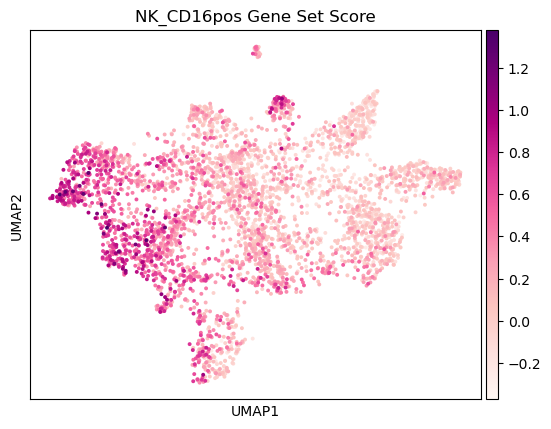

In [55]:
valid_NK_CD16pos_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_NK_CD16pos, 'NK_CD16pos_score')

# Visualize the results if valid genes were found
if valid_NK_CD56pos_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='NK_CD16pos_score', cmap='RdPu', wspace=0.1, ncols=5, title='NK_CD16pos Gene Set Score')

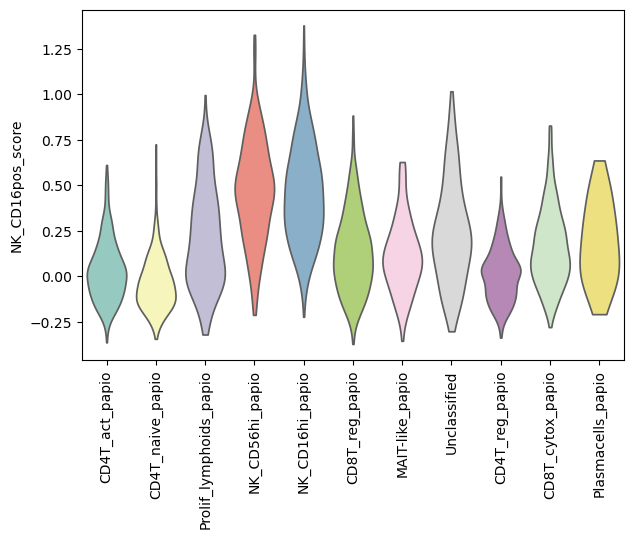

In [56]:
sc.pl.violin(
    LYMPHOIDS_harmony,
    keys="NK_CD16pos_score",
    groupby="leiden_named_08",
    rotation=90,
    stripplot=False
)

# B cells 

In [50]:
gene_set_B_cells = ["Papio_anubis_AFF3", "Papio_anubis_BANK1", "Papio_anubis_ARHGAP24", "Papio_anubis_RALGPS2", "Papio_anubis_MARCH1", "Papio_anubis_LINC00926", "Papio_anubis_BACH2", "Papio_anubis_FCRL1", "Papio_anubis_BLK", "Papio_anubis_OSBPL10", "Papio_anubis_MEF2C", "Papio_anubis_GNG7", "Papio_anubis_EBF1", "Papio_anubis_CD74", "Papio_anubis_FCHSD2", "Papio_anubis_MS4A1", "Papio_anubis_PRKCB", "Papio_anubis_RCSD1", "Papio_anubis_TRIO", "Papio_anubis_MTSS1", "Papio_anubis_ADAM28", "Papio_anubis_FAM129C", "Papio_anubis_PAX5", "Papio_anubis_LYN", "Papio_anubis_LARGE1", "Papio_anubis_BCL11A", "Papio_anubis_SEL1L3", "Papio_anubis_STX7", "Papio_anubis_SIPA1L3", "Papio_anubis_PRKCE", "Papio_anubis_ADK", "Papio_anubis_ITPR1", "Papio_anubis_MGAT5", "Papio_anubis_AC120193.1", "Papio_anubis_STRBP", "Papio_anubis_IGHM", "Papio_anubis_PLEKHG1", "Papio_anubis_SYK", "Papio_anubis_CDK14", "Papio_anubis_CAMK1D", "Papio_anubis_WDFY4", "Papio_anubis_ST6GAL1", "Papio_anubis_SNX29", "Papio_anubis_UVRAG", "Papio_anubis_ZCCHC7", "Papio_anubis_PLCG2", "Papio_anubis_CARMIL1", "Papio_anubis_UBE2E2", "Papio_anubis_GRK3", "Papio_anubis_KHDRBS2", "Papio_anubis_SETBP1", "Papio_anubis_NCOA3", "Papio_anubis_FGD2", "Papio_anubis_COBLL1", "Papio_anubis_SWAP70", "Papio_anubis_AC119396.1", "Papio_anubis_SNX2", "Papio_anubis_HDAC9", "Papio_anubis_FCRL2", "Papio_anubis_ADAM19", "Papio_anubis_ST6GALNAC3", "Papio_anubis_COL19A1", "Papio_anubis_LIX1-AS1", "Papio_anubis_RIPOR2", "Papio_anubis_TBC1D22A", "Papio_anubis_CIITA", "Papio_anubis_MICAL3", "Papio_anubis_RAB30", "Papio_anubis_ANKRD44", "Papio_anubis_BLNK", "Papio_anubis_DIP2B", "Papio_anubis_USP6NL", "Papio_anubis_BIRC3", "Papio_anubis_CCSER1", "Papio_anubis_POU2F2", "Papio_anubis_ANGPTL1", "Papio_anubis_DMXL1", "Papio_anubis_TRAK1", "Papio_anubis_MEF2A", "Papio_anubis_SIPA1L1", "Papio_anubis_BMP2K", "Papio_anubis_CD22", "Papio_anubis_DENND5B", "Papio_anubis_MAP3K1", "Papio_anubis_TFEB", "Papio_anubis_AUTS2", "Papio_anubis_TPD52", "Papio_anubis_CD37", "Papio_anubis_SP100", "Papio_anubis_SP110", "Papio_anubis_SMAP2", "Papio_anubis_TMEM154", "Papio_anubis_AP002075.1", "Papio_anubis_RHEX", "Papio_anubis_TCF4", "Papio_anubis_SLC9A7", "Papio_anubis_RUBCNL", "Papio_anubis_CNR2", "Papio_anubis_RB1", "Papio_anubis_TMEM131L"]

Gene set score 'B_cells_score' calculated using 39 genes.
Valid genes: Papio_anubis_AFF3, Papio_anubis_BANK1, Papio_anubis_ARHGAP24, Papio_anubis_RALGPS2, Papio_anubis_BACH2, Papio_anubis_OSBPL10, Papio_anubis_MEF2C, Papio_anubis_EBF1, Papio_anubis_CD74, Papio_anubis_TRIO, Papio_anubis_MTSS1, Papio_anubis_ADAM28, Papio_anubis_LYN, Papio_anubis_LARGE1, Papio_anubis_BCL11A, Papio_anubis_ITPR1, Papio_anubis_SYK, Papio_anubis_CDK14, Papio_anubis_SNX29, Papio_anubis_PLCG2, Papio_anubis_CARMIL1, Papio_anubis_UBE2E2, Papio_anubis_GRK3, Papio_anubis_SETBP1, Papio_anubis_FGD2, Papio_anubis_FCRL2, Papio_anubis_ADAM19, Papio_anubis_ST6GALNAC3, Papio_anubis_MICAL3, Papio_anubis_BLNK, Papio_anubis_USP6NL, Papio_anubis_ANGPTL1, Papio_anubis_SIPA1L1, Papio_anubis_BMP2K, Papio_anubis_DENND5B, Papio_anubis_AUTS2, Papio_anubis_TPD52, Papio_anubis_TCF4, Papio_anubis_RUBCNL

Gene Scores:
                   Gene  Mean Expression  Variance            CV
    Papio_anubis_SETBP1     4.750683e-08  0.999735  2.

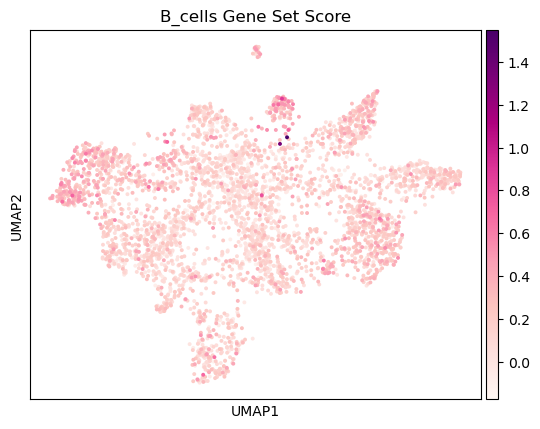

In [51]:
valid_B_cells_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_B_cells, 'B_cells_score')

# Visualize the results if valid genes were found
if valid_B_cells_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='B_cells_score', cmap='RdPu', wspace=0.1, ncols=5, title='B_cells Gene Set Score')

# Proliferation Lymphoids 

In [52]:
gene_set_prolif_LYMPH = ["Papio_anubis_SMC4", "Papio_anubis_NSD2", "Papio_anubis_CENPP", "Papio_anubis_EZH2", "Papio_anubis_KNL1", "Papio_anubis_FANCI", "Papio_anubis_TOP2A", "Papio_anubis_DLEU2", "Papio_anubis_MELK", "Papio_anubis_AC091057.6", "Papio_anubis_LINC01572", "Papio_anubis_ASPM", "Papio_anubis_NUSAP1", "Papio_anubis_TMPO", "Papio_anubis_MIR4435-2HG", "Papio_anubis_ATAD2", "Papio_anubis_DIAPH3", "Papio_anubis_NCAPG2", "Papio_anubis_BRIP1", "Papio_anubis_RBL1", "Papio_anubis_C12orf75", "Papio_anubis_CENPE", "Papio_anubis_POLQ", "Papio_anubis_Z94721.1", "Papio_anubis_CIT", "Papio_anubis_C21orf58", "Papio_anubis_KIF18B", "Papio_anubis_MKI67", "Papio_anubis_KNTC1", "Papio_anubis_KCNQ5", "Papio_anubis_WWOX", "Papio_anubis_TACC3", "Papio_anubis_SRGAP2", "Papio_anubis_DNMT1", "Papio_anubis_SCMH1", "Papio_anubis_ATAD5", "Papio_anubis_FAF1", "Papio_anubis_STAG1", "Papio_anubis_KIF11", "Papio_anubis_PTPRJ", "Papio_anubis_PBX3", "Papio_anubis_BRCA2", "Papio_anubis_CDC27", "Papio_anubis_KIF20B", "Papio_anubis_CKAP5", "Papio_anubis_DOCK2", "Papio_anubis_KIF15", "Papio_anubis_POLA1", "Papio_anubis_HELLS", "Papio_anubis_STIL", "Papio_anubis_LMNB1", "Papio_anubis_SCLT1", "Papio_anubis_CENPK", "Papio_anubis_C2orf48", "Papio_anubis_PRIM2", "Papio_anubis_RFC3", "Papio_anubis_XPO1", "Papio_anubis_GTSE1", "Papio_anubis_FCHSD2", "Papio_anubis_ASXL1", "Papio_anubis_MYO9B", "Papio_anubis_TUBA1B", "Papio_anubis_DNA2", "Papio_anubis_CENPF", "Papio_anubis_CCDC18", "Papio_anubis_KCNAB2", "Papio_anubis_LRRFIP1", "Papio_anubis_NDC80", "Papio_anubis_SH2D3C", "Papio_anubis_KIF14", "Papio_anubis_PDS5B", "Papio_anubis_CCDC14", "Papio_anubis_MMS22L", "Papio_anubis_HMGN2", "Papio_anubis_KIF4A", "Papio_anubis_CEP192", "Papio_anubis_RPTOR", "Papio_anubis_INPP4A", "Papio_anubis_ANKRD36C", "Papio_anubis_MPHOSPH9", "Papio_anubis_BUB1B", "Papio_anubis_CEP128", "Papio_anubis_RSRC1", "Papio_anubis_TTF2", "Papio_anubis_VRK1", "Papio_anubis_MIR181A1HG", "Papio_anubis_COTL1", "Papio_anubis_APOLD1", "Papio_anubis_SUZ12", "Papio_anubis_KIF23", "Papio_anubis_NFATC2IP", "Papio_anubis_AUTS2", "Papio_anubis_CDCA2", "Papio_anubis_NCAPD3", "Papio_anubis_R3HDM1", "Papio_anubis_TPX2", "Papio_anubis_SRGAP2B", "Papio_anubis_HMGB2", "Papio_anubis_FANCC", "Papio_anubis_CIITA"]


Gene set score 'prolif_LYMPH_score' calculated using 24 genes.
Valid genes: Papio_anubis_SMC4, Papio_anubis_EZH2, Papio_anubis_ASPM, Papio_anubis_ATAD2, Papio_anubis_DIAPH3, Papio_anubis_BRIP1, Papio_anubis_CENPE, Papio_anubis_MKI67, Papio_anubis_KCNQ5, Papio_anubis_WWOX, Papio_anubis_TACC3, Papio_anubis_BRCA2, Papio_anubis_CKAP5, Papio_anubis_HELLS, Papio_anubis_SCLT1, Papio_anubis_DNA2, Papio_anubis_CENPF, Papio_anubis_KIF14, Papio_anubis_MMS22L, Papio_anubis_BUB1B, Papio_anubis_CEP128, Papio_anubis_COTL1, Papio_anubis_AUTS2, Papio_anubis_TPX2

Gene Scores:
               Gene  Mean Expression  Variance            CV
  Papio_anubis_WWOX     3.840978e-08  0.999735  2.603159e+07
 Papio_anubis_BRCA2     3.234507e-08  0.999735  3.091251e+07
  Papio_anubis_DNA2     2.830194e-08  0.999735  3.532859e+07
 Papio_anubis_CKAP5     2.653307e-08  0.999735  3.768382e+07
  Papio_anubis_SMC4     2.223724e-08  0.999735  4.496365e+07
 Papio_anubis_CENPE     2.021567e-08  0.999735  4.946002e+07
 Papio_

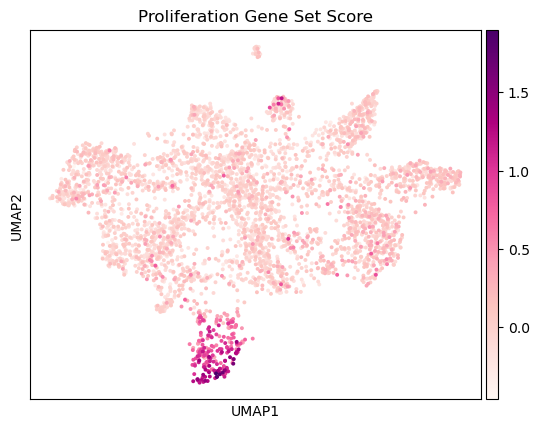

In [53]:
valid_prolif_genes = calculate_gene_set_score(LYMPHOIDS_harmony, gene_set_prolif_LYMPH, 'prolif_LYMPH_score')

# Visualize the results if valid genes were found
if valid_prolif_genes:
    sc.pl.umap(LYMPHOIDS_harmony, color='prolif_LYMPH_score', cmap='RdPu', wspace=0.1, ncols=5, title='Proliferation Gene Set Score')


In [45]:
# 